# Visualiton des donnes Vitamin carenas

1) Explotion des donnees  

In [92]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [50]:
fichier = "../data_csv/raw/vitamin_deficiency_disease_dataset_20260123.ods"
df = pd.read_excel(fichier, engine='odf')
print("csv ok")
print(f"{df.shape[0]} ligne avec tete et {df.shape[1]} colons")


csv ok
4000 ligne avec tete et 34 colons


In [51]:
print("Data info\nexplottaion de base de donne")
print("--"*25)
df.info(34)

Data info
explottaion de base de donne
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   str    
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   str    
 4   alcohol_consumption        2722 non-null   str    
 5   exercise_level             4000 non-null   str    
 6   diet_type                  4000 non-null   str    
 7   sun_exposure               4000 non-null   str    
 8   income_level               4000 non-null   str    
 9   latitude_region            4000 non-null   str    
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda    

In [52]:
print("Statisctique ")
print("--"*25)
df.describe()

Statisctique 
--------------------------------------------------


,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,hemoglobin_g_dl,serum_vitamin_d_ng_ml,serum_vitamin_b12_pg_ml,serum_folate_ng_ml,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_multiple_deficiencies
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,50.766250,26.105325,90.770850,89.199075,72.216388,89.946125,62.743225,90.382275,82.586300,76.211125,14.027200,21.744050,255.514725,10.831725,1.86725,0.102250,0.269250,0.043500,0.300750,0.265750,0.351250,0.303000,0.161750,0.347250
std,19.306237,4.922746,37.083534,37.505809,42.831000,37.444649,37.396636,37.563684,36.359131,33.226984,1.665629,13.768642,158.934806,4.965111,1.79581,0.303015,0.443626,0.204005,0.458641,0.441787,0.477421,0.459613,0.368267,0.476156
min,18.000000,15.000000,10.000000,10.000000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,8.200000,5.000000,100.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,22.800000,62.600000,60.975000,40.730000,61.700000,32.700000,61.800000,55.600000,51.400000,12.900000,11.700000,121.200000,7.100000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,26.200000,85.500000,83.500000,62.270000,84.050000,55.600000,84.800000,77.100000,71.250000,14.100000,18.400000,214.850000,10.000000,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,67.000000,29.400000,115.300000,113.000000,93.317500,114.100000,84.500000,115.200000,105.300000,95.900000,15.100000,27.900000,338.400000,13.800000,3.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,84.000000,45.000000,219.000000,250.000000,275.600000,237.600000,243.600000,226.600000,232.700000,211.400000,18.000000,80.000000,1138.100000,25.000000,9.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [53]:
print("Valeur manque")
print("--"*25)

#compte tous les valuer null dans df (dataframe) et calcul pourcentage
val_nul_compt = df.isnull().sum()
val_nul_percantage = (val_nul_compt/len(df))*100

#print(val_nul_compt,val_nul_percantage)  #ok calcule

#create nouvelle datafrace pour afficer
null_val_df = pd.DataFrame({"Valeur null": val_nul_compt
                           ,"Pourcentage": val_nul_percantage})

#re organize decorisent 
null_val_df = null_val_df[null_val_df['Valeur null']>0].sort_values('Valeur null', ascending=False)



print(null_val_df)


Valeur manque
--------------------------------------------------
                     Valeur null  Pourcentage
symptoms_list               1328        33.20
alcohol_consumption         1278        31.95


### Interprétation : Valeurs manquantes

Le dataset contient deux colonnes avec des valeurs manquantes :

- **symptoms_list** : 1328 valeurs manquantes (33.2%) — cela est logique car 
les patients sains (diagnostic "Healthy") n'ont pas de symptômes à lister, 
donc ces cases sont vides naturellement.

- **alcohol_consumption** : 1278 valeurs manquantes (31.95%) — certains patients 
n'ont pas renseigné leur consommation d'alcool, ce qui est courant dans les 
données médicales car c'est une information sensible.

Ces valeurs manquantes ne sont pas problématiques pour la visualisation car 
elles ont une explication logique et ne concernent pas les colonnes de vitamines.

In [54]:
#class / malaidie distribuition analyse
print("Distriburion class(maladie)")
print("--"*25)

class_compt= df['disease_diagnosis'].value_counts()

class_df = pd.DataFrame({'nombre de patien':(class_compt), 
                         'Pourcentage':((class_compt/class_compt.sum())*100)
                         })

#pour verifier ajouter les ligne + et % loc -> location
class_df.loc['Total']=[class_compt.sum(),class_df['Pourcentage'].sum()]


#enleve decimale
class_df['nombre de patien'] = class_df['nombre de patien'].astype(int)
class_df['Pourcentage'] = class_df['Pourcentage'].round(2)

print(class_df)



Distriburion class(maladie)
--------------------------------------------------
                      nombre de patien  Pourcentage
disease_diagnosis                                  
Healthy                           1509        37.72
Anemia                            1245        31.13
Rickets_Osteomalacia              1029        25.72
Night_Blindness                    122         3.05
Scurvy                              95         2.38
Total                             4000       100.00


### Interprétation : Distribution des maladies

Le dataset contient 4000 patients répartis en 5 catégories :

- **Healthy (37.72%)** : la catégorie la plus représentée, ce qui est réaliste 
car tous les patients ne sont pas malades.

- **Anemia (31.13%)** et **Rickets_Osteomalacia (25.72%)** : très bien représentées, 
ce qui permettra au modèle de bien les apprendre.

- **Night_Blindness (3.05%)** et **Scurvy (2.38%)** : très peu représentées, 
c'est un **déséquilibre de classes** important. Ces deux maladies rares risquent 
d'être mal prédites par un modèle car il y a trop peu d'exemples.

 Ce déséquilibre est à prendre en compte pour la suite du projet 
(notamment avec des techniques comme SMOTE pour rééquilibrer les classes).

In [55]:
print("Analyse des vitamin niveau par malaidie")
print("--"*60)

#colons vitamin
vitamin_cols = [
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda',
    'vitamin_d_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda',
    'serum_vitamin_d_ng_ml',
    'serum_vitamin_b12_pg_ml',
    'serum_folate_ng_ml',
    'hemoglobin_g_dl',
]


#pour chauque maladie moyenne vitamin 
vitamin_par_maladie = df.groupby('disease_diagnosis')[vitamin_cols].mean()

#renomer 
vitamin_par_maladie.columns = [
    'Vit A (%RDA)',
    'Vit C (%RDA)',
    'Vit D (%RDA)',
    'Vit B12 (%RDA)',
    'Folate (%RDA)',
    'Calcium (%RDA)',
    'Fer (%RDA)',
    'Sérum Vit D (ng/ml)',
    'Sérum B12 (pg/ml)',
    'Sérum Folate (ng/ml)',
    'Hémoglobine (g/dl)'
]



# Arrondir
vitamin_par_maladie = vitamin_par_maladie.round(2)

# Afficher avec display (plus propre!)
display(vitamin_par_maladie)



Analyse des vitamin niveau par malaidie
------------------------------------------------------------------------------------------------------------------------


,Vit A (%RDA),Vit C (%RDA),Vit D (%RDA),Vit B12 (%RDA),Folate (%RDA),Calcium (%RDA),Fer (%RDA),Sérum Vit D (ng/ml),Sérum B12 (pg/ml),Sérum Folate (ng/ml),Hémoglobine (g/dl)
disease_diagnosis,,,,,,,,,,,
Anemia,87.95,84.78,71.44,43.17,82.40,74.83,64.01,21.49,181.00,9.84,13.81
Healthy,107.10,104.64,101.46,93.90,108.37,101.78,98.20,30.52,371.03,12.97,14.41
Night_Blindness,30.57,72.93,75.24,52.11,73.76,67.68,63.72,22.35,220.11,8.87,13.72
Rickets_Osteomalacia,78.82,80.03,31.41,43.62,77.48,67.30,61.87,9.52,185.70,9.31,13.81
Scurvy,75.16,22.11,55.94,45.24,70.33,64.15,58.21,17.25,198.78,8.86,13.64


### Interprétation : Niveaux moyens de vitamines par maladie

Le tableau confirme des patterns biologiques très cohérents :

- **Healthy** : tous les niveaux sont élevés (Vit A ~107%, Vit C ~105%, Vit D ~101%) 
et l'hémoglobine est la plus haute (14.41 g/dl), ce qui est logique pour des patients sains.

- **Night_Blindness** : carence très marquée en **Vitamine A (30.57% RDA)**, 
ce qui est cohérent car la vitamine A est essentielle à la vision nocturne.

- **Scurvy** : carence très marquée en **Vitamine C (22.11% RDA)**, 
le scorbut étant directement causé par un manque de vitamine C.

- **Rickets_Osteomalacia** : carence très marquée en **Vitamine D (31.41% RDA)** 
et **Sérum Vit D très bas (9.52 ng/ml)**, cohérent car le rachitisme est causé 
par un manque de vitamine D affectant les os.

- **Anemia** : carence en **Fer (64.01% RDA)** et **hémoglobine basse (13.81 g/dl)**, 
typique de l'anémie ferriprive.

Ces résultats valident la qualité du dataset : chaque maladie 
correspond bien à sa carence vitaminique attendue.

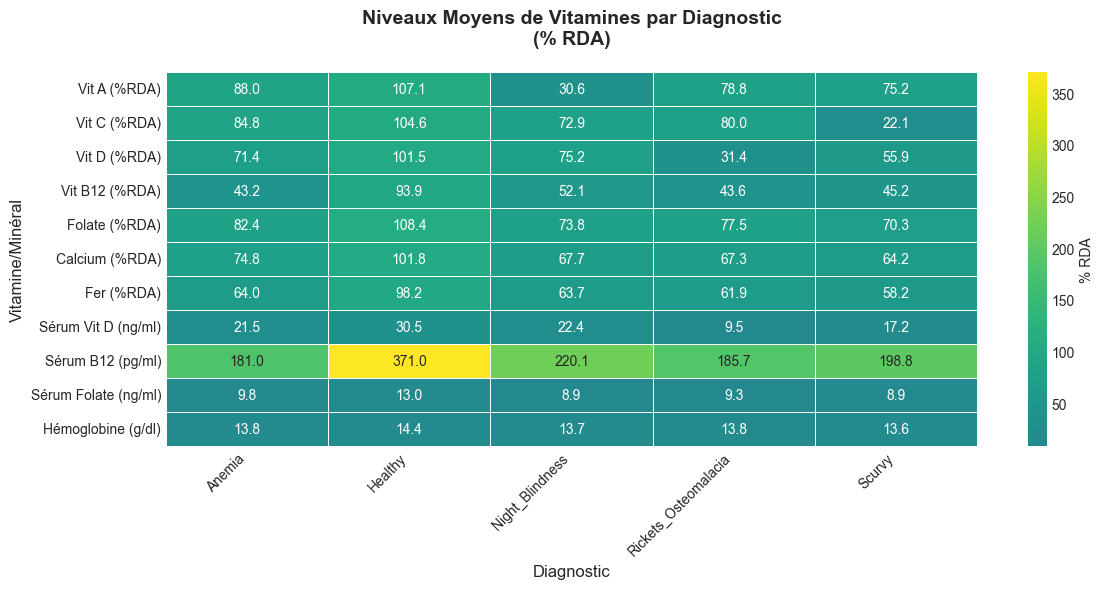

In [56]:
plt.figure(figsize=(12,6))

sns.heatmap(
    vitamin_par_maladie.T, # transforme dataframe
    annot=True,
    fmt='.1f' ,
    cmap='viridis',         
    center=30,             
    linewidths=0.5,        
    cbar_kws={'label': '% RDA'}
)

# Başlık ve etiketler
plt.title('Niveaux Moyens de Vitamines par Diagnostic\n(% RDA)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Diagnostic', fontsize=12)
plt.ylabel('Vitamine/Minéral', fontsize=12)

# X eksenini döndür
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Layout düzenle
plt.tight_layout()
plt.show()





### Interprétation : Heatmap des niveaux de vitamines par diagnostic

La heatmap confirme visuellement les carences spécifiques à chaque maladie :

- **Healthy** se distingue clairement avec les couleurs les plus claires 
(jaune/vert clair), notamment le Sérum B12 à 371 pg/ml — les patients sains 
ont des niveaux optimaux pour toutes les vitamines.

- **Night_Blindness** : la case **Vit A (30.6%)** est très sombre, 
confirmant une carence sévère et spécifique en vitamine A.

- **Rickets_Osteomalacia** : les cases **Vit D (31.4%)** et 
**Sérum Vit D (9.5 ng/ml)** sont les plus sombres de leur ligne, 
ce qui confirme le lien direct entre manque de vitamine D et rachitisme.

- **Scurvy** : la case **Vit C (22.1%)** est la plus sombre de sa ligne, 
carence caractéristique du scorbut.

- **Le Sérum B12** domine visuellement toute la heatmap (valeurs entre 181 
et 371 pg/ml) car son échelle est différente des autres vitamines en %RDA, 
ce qui explique les couleurs très claires sur cette ligne.

 Cette visualisation permet d'identifier d'un seul coup d'œil 
quelle vitamine est déficiente pour chaque maladie.

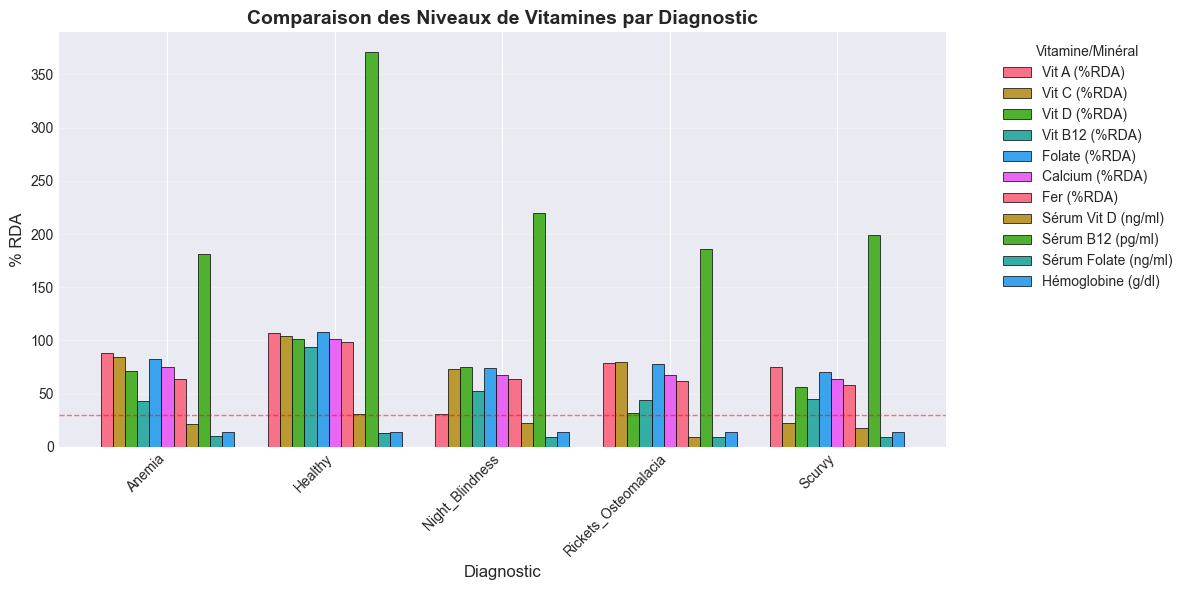

In [57]:
#bar graphe par maladie

vitamin_par_maladie.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8,
    edgecolor = 'black',
    linewidth=0.5
)

plt.title('Comparaison des Niveaux de Vitamines par Diagnostic', 
          fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic', fontsize=12)
plt.ylabel('% RDA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vitamine/Minéral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Seuil (30%)')
plt.tight_layout()
plt.show()



### Interprétation : Comparaison des niveaux de vitamines par diagnostic

Ce graphique confirme visuellement les carences caractéristiques de chaque maladie :

- **Healthy** : toutes les barres sont au-dessus du seuil rouge (30% RDA), 
avec le Sérum B12 qui domine largement à 371 pg/ml. C'est le profil 
vitaminique le plus équilibré.

- **Night_Blindness** : la barre **Vit A** est la plus basse de ce groupe 
et passe sous le seuil rouge (30.6% RDA), confirmant la carence spécifique 
en vitamine A.

- **Rickets_Osteomalacia** : la barre **Vit D** chute très bas (31.4% RDA) 
et le **Sérum Vit D** est quasi nul (9.5 ng/ml), illustrant clairement 
le manque de vitamine D responsable du rachitisme.

- **Scurvy** : la barre **Vit C** est la plus basse de tous les groupes 
(22.1% RDA), bien en dessous du seuil rouge, typique du scorbut.

- **Anemia** : profil globalement bas pour toutes les vitamines, 
avec le **Fer** et l'**Hémoglobine** particulièrement affectés.

 Le Sérum B12 (barres vertes très hautes) écrase visuellement 
les autres valeurs car son échelle est différente — c'est une limite 
de ce graphique qui mélange des unités différentes (%RDA et ng/ml).

# Analyse de corelation entre les variable
--------------------


In [58]:
#choisir colons numerique

numerique_colon = df.select_dtypes(include=['float64','int64']).columns.tolist() #les flotons et reels 

correlation_matrice = df[numerique_colon].corr()


matrice_df = pd.DataFrame({'Nombre du numerique ': len(numerique_colon),'Taille de matrice':correlation_matrice.shape})


#matrice_df
#correlation_matrice




On va visualiser avec une Matrice de corrélation pour toutes les variables

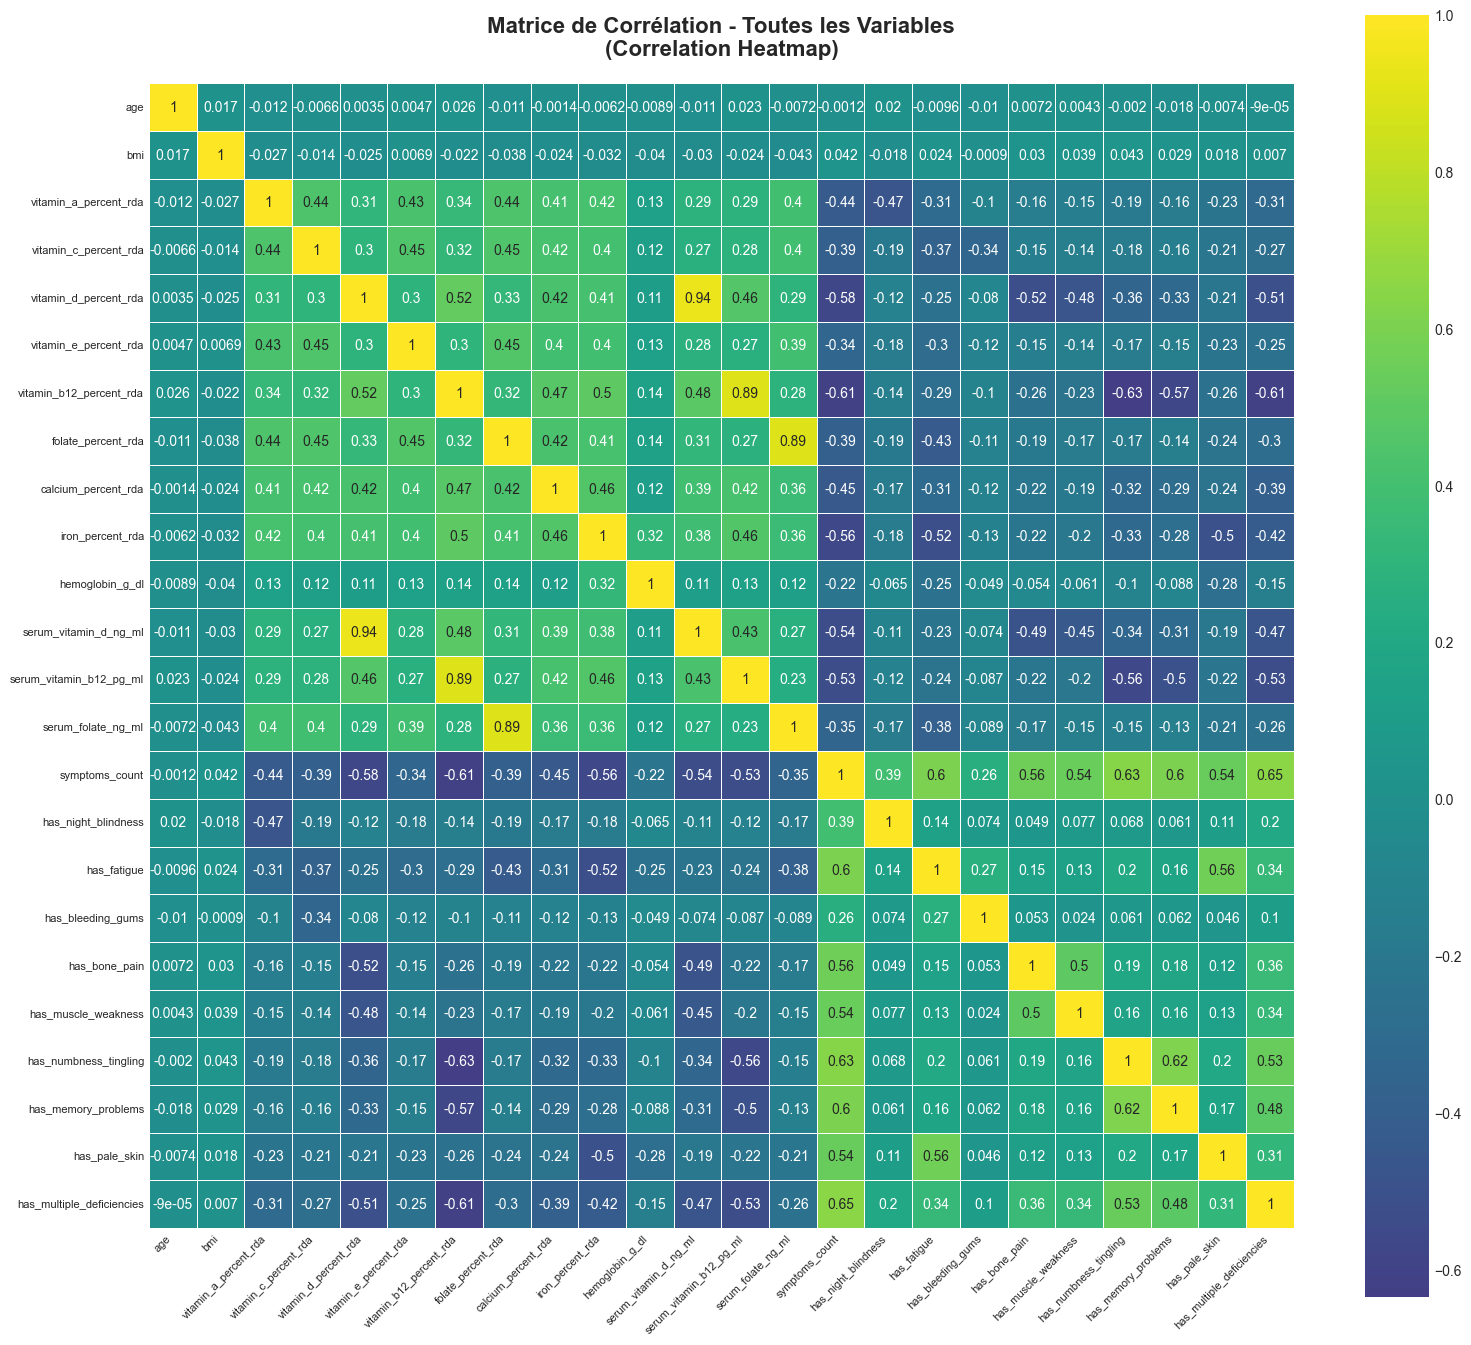

In [59]:
plt.figure(figsize=(16,14))

sns.heatmap(
    correlation_matrice,
    annot=True,
    cmap='viridis',
    center=0,
    square=True,
    linewidths=0.5,
    cbar={'label':'Correlation','shirink':0.8}

)

plt.title('Matrice de Corrélation - Toutes les Variables\n(Correlation Heatmap)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()






### Interprétation : Matrice de corrélation - Toutes les variables

**Corrélations fortes positives (cases jaunes ~1.0) :**
- **vitamin_d_percent_rda ↔ serum_vitamin_d_ng_ml (0.94)** : très logique, 
plus on consomme de vitamine D, plus son taux sanguin est élevé.
- **vitamin_b12_percent_rda ↔ serum_vitamin_b12_pg_ml (0.89)** : même logique 
pour la vitamine B12.
- **folate_percent_rda ↔ serum_folate_ng_ml (0.89)** : idem pour le folate.
- **has_numbness_tingling ↔ has_memory_problems (0.62)** : ces deux symptômes 
apparaissent souvent ensemble, caractéristiques d'une carence en B12.

**Corrélations fortes négatives (cases sombres ~-0.6) :**
- **symptoms_count ↔ vitamines** : plus les niveaux de vitamines sont bas, 
plus le nombre de symptômes augmente — ce qui est médicalement cohérent.
- **has_multiple_deficiencies ↔ vitamin_b12 (-0.61)** et 
**vitamin_d (-0.51)** : les patients avec plusieurs carences ont 
logiquement des niveaux de vitamines très bas.

**À noter :**
- **age et bmi** n'ont quasiment aucune corrélation avec les vitamines 
(valeurs proches de 0), ce qui suggère que l'âge et le poids seuls 
ne déterminent pas les carences dans ce dataset.

  Ces corrélations valident la cohérence biologique du dataset et confirment quelles variables seront les plus utiles pour la prédiction.

On va focuser seulment les vitamisn 

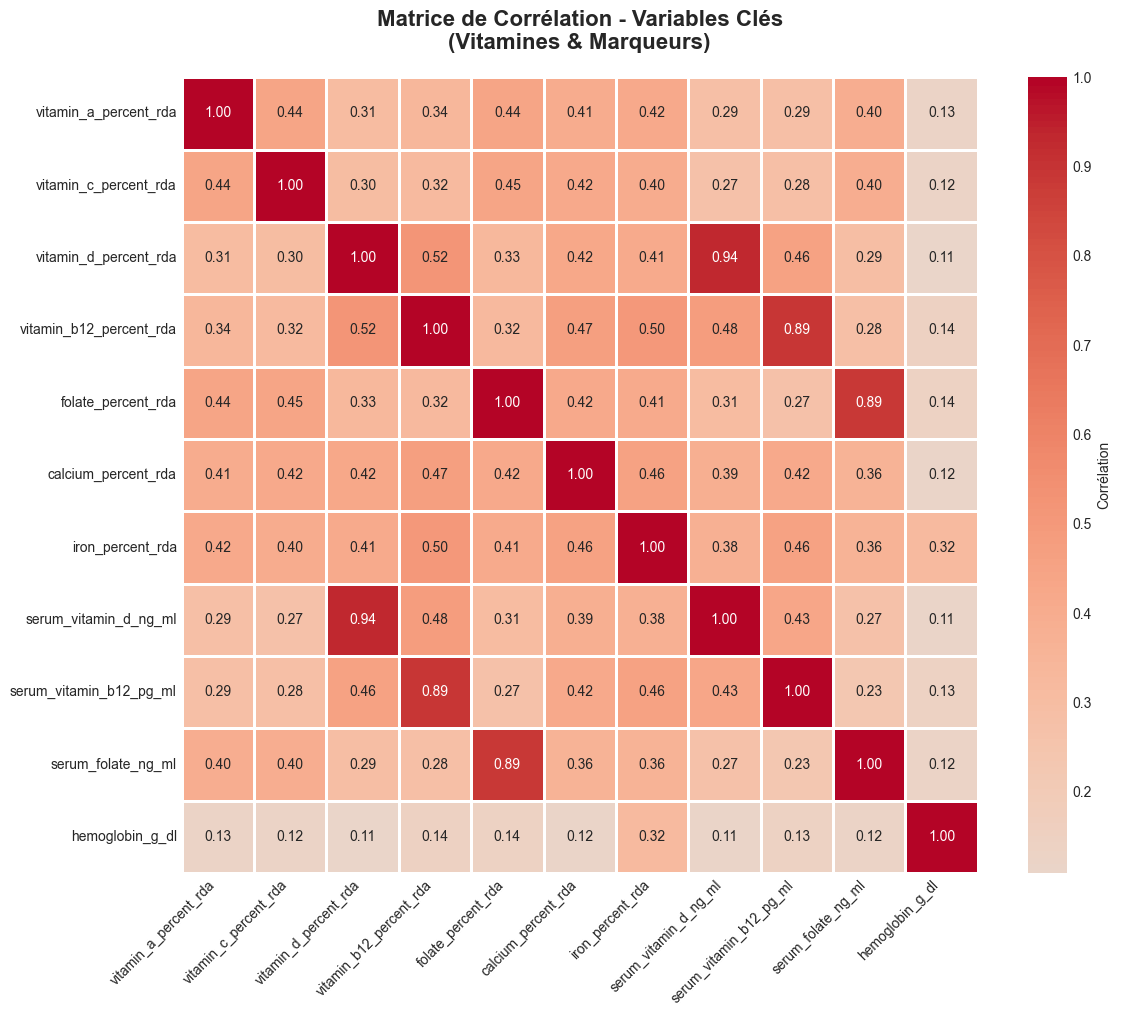

In [60]:
#specifique  correlation 


selection_corr =df[vitamin_cols].corr()


# Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    selection_corr,
    annot=True,            # ← Şimdi sayıları göster!
    fmt='.2f',             # 2 ondalık
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation'}
)

plt.title('Matrice de Corrélation - Variables Clés\n(Vitamines & Marqueurs)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()




### Interprétation : Matrice de corrélation - Variables clés (Vitamines & Marqueurs)

Cette matrice focalisée sur les vitamines et marqueurs biologiques 
révèle des liens très clairs :

**Corrélations très fortes (cases rouge foncé > 0.85) :**
- **vitamin_d_percent_rda ↔ serum_vitamin_d_ng_ml (0.94)** : 
la corrélation la plus forte — l'apport en vitamine D se reflète 
directement dans le sang.
- **vitamin_b12_percent_rda ↔ serum_vitamin_b12_pg_ml (0.89)** : 
même lien direct entre apport et taux sanguin de B12.
- **folate_percent_rda ↔ serum_folate_ng_ml (0.89)** : 
idem pour le folate.

**Corrélations modérées (0.40 - 0.52) :**
- Toutes les vitamines entre elles ont des corrélations modérées (~0.30-0.52), 
ce qui signifie qu'une personne carencée en une vitamine 
a tendance à être carencée en d'autres également.
- **vitamin_b12 ↔ vitamin_d (0.52)** est la plus forte entre vitamines, 
ce qui peut s'expliquer par des comportements alimentaires similaires.

**Hémoglobine (dernière ligne) :**
- L'hémoglobine a des corrélations faibles avec toutes les vitamines 
sauf le **fer (0.32)**, ce qui est cohérent car l'anémie est 
principalement liée au fer et non aux autres vitamines.

 Cette matrice ciblée est plus lisible que la précédente et confirme que les marqueurs sériques sont de très bons indicateurs des apports 
réels en vitamines.

On peut observer que il ya une fort relations quelques variables. On va continue chercher les relation entre tous les variables.

In [61]:
#top 10 
print("Top 10 Corrélations Positives (les plus fortes):")
print("=" * 60)

# Correlation matrice 2D -> 1D
corr_pairs = correlation_matrice.unstack()

# enleve correlation idem
#corr_pairs = corr_pairs[(corr_pairs < 1]
corr_pairs = corr_pairs[(corr_pairs < 1)  & (corr_pairs > -1)]



# top 10
top_positive = corr_pairs.nlargest(552) # faite attaaatiojsasd apres observe valuer negative

for (var1, var2), corr in top_positive.items():
    print(f"{var1:30s} ↔ {var2:30s} : {corr:.3f}")

Top 10 Corrélations Positives (les plus fortes):
vitamin_d_percent_rda          ↔ serum_vitamin_d_ng_ml          : 0.936
serum_vitamin_d_ng_ml          ↔ vitamin_d_percent_rda          : 0.936
vitamin_b12_percent_rda        ↔ serum_vitamin_b12_pg_ml        : 0.893
serum_vitamin_b12_pg_ml        ↔ vitamin_b12_percent_rda        : 0.893
folate_percent_rda             ↔ serum_folate_ng_ml             : 0.887
serum_folate_ng_ml             ↔ folate_percent_rda             : 0.887
symptoms_count                 ↔ has_multiple_deficiencies      : 0.653
has_multiple_deficiencies      ↔ symptoms_count                 : 0.653
symptoms_count                 ↔ has_numbness_tingling          : 0.630
has_numbness_tingling          ↔ symptoms_count                 : 0.630
has_numbness_tingling          ↔ has_memory_problems            : 0.616
has_memory_problems            ↔ has_numbness_tingling          : 0.616
symptoms_count                 ↔ has_memory_problems            : 0.601
has_memory_prob

### Interprétation : Top des corrélations positives et négatives

**Top corrélations positives (les plus fortes) :**

- **serum_vitamin_d ↔ vitamin_d (0.936)**, **serum_b12 ↔ vitamin_b12 (0.893)**, 
**serum_folate ↔ folate (0.887)** : les 3 corrélations les plus fortes 
confirment que les marqueurs sériques reflètent parfaitement les apports 
alimentaires — ce sont des paires biologiquement logiques.

- **symptoms_count ↔ has_multiple_deficiencies (0.653)** : plus un patient 
a de carences, plus il accumule de symptômes, ce qui est attendu.

- **has_numbness_tingling ↔ has_memory_problems (0.616)** et 
**has_numbness_tingling ↔ symptoms_count (0.630)** : les engourdissements 
et troubles de mémoire apparaissent souvent ensemble, 
typiques d'une carence sévère en B12.

- **has_fatigue ↔ has_pale_skin (0.560)** : deux symptômes classiques 
de l'anémie qui coexistent fréquemment.

**Corrélations négatives importantes :**

- **vitamin_b12 ↔ has_numbness_tingling (-0.635)** et 
**vitamin_b12 ↔ symptoms_count (-0.612)** : plus le niveau de B12 est bas, 
plus les engourdissements et le nombre de symptômes augmentent — 
relation inverse parfaitement cohérente médicalement.

 Ces résultats confirment que les symptômes et les niveaux de vitamines sont fortement liés, ce qui est très encourageant pour la prédiction 
 des maladies par un modèle de machine learning.

In [62]:
corr_pairs.shape[0]



552

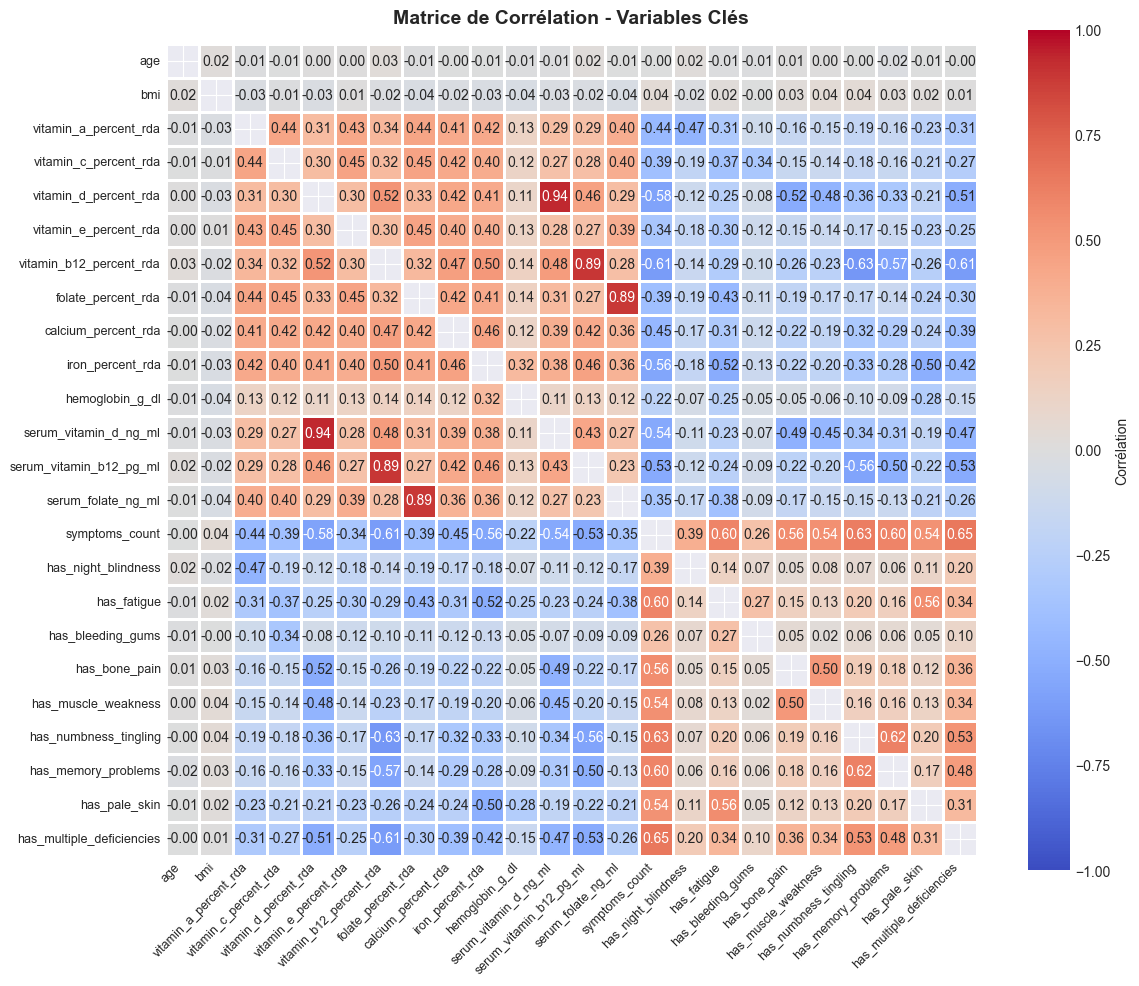

In [63]:
# Heatmap - Corriger
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrice[correlation_matrice<1],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',     # ← coolwarm kullan
    vmin=-1,             # ← Min değer
    vmax=1,              # ← Max değer
    center=0,            # ← Şimdi çalışır!
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation'}
)

plt.title('Matrice de Corrélation - Variables Clés', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Interprétation : Matrice de corrélation complète (coolwarm)

Cette version avec l'échelle coolwarm (rouge = positif, bleu = négatif) 
permet de mieux visualiser les deux types de relations :

**Zones rouges (corrélations positives) :**
- Le bloc **vitamines ↔ marqueurs sériques** reste très rouge 
(vitamin_d/serum_d : 0.94, b12/serum_b12 : 0.89, folate/serum_folate : 0.89).
- Le bloc **symptômes entre eux** est rouge (has_numbness ↔ has_memory : 0.62, 
has_bone_pain ↔ has_muscle_weakness : 0.50) — les symptômes s'accumulent ensemble.

**Zones bleues (corrélations négatives) :**
- Le bloc **vitamines ↔ symptômes** est clairement bleu — quand les vitamines 
baissent, les symptômes augmentent. La plus forte : 
vitamin_b12 ↔ has_numbness_tingling (-0.63).
- **iron_percent_rda ↔ has_pale_skin (-0.50)** et 
**vitamin_d ↔ has_bone_pain (-0.52)** : carences spécifiques 
liées à leurs symptômes respectifs.

**Age et BMI (2 premières lignes/colonnes) :**
- Quasiment tout blanc (proche de 0), confirmant que ces variables 
démographiques n'influencent pas les carences dans ce dataset.

 Cette visualisation est la plus complète — elle montre simultanément 
les relations positives et négatives et confirme la cohérence 
médicale de toutes les variables.

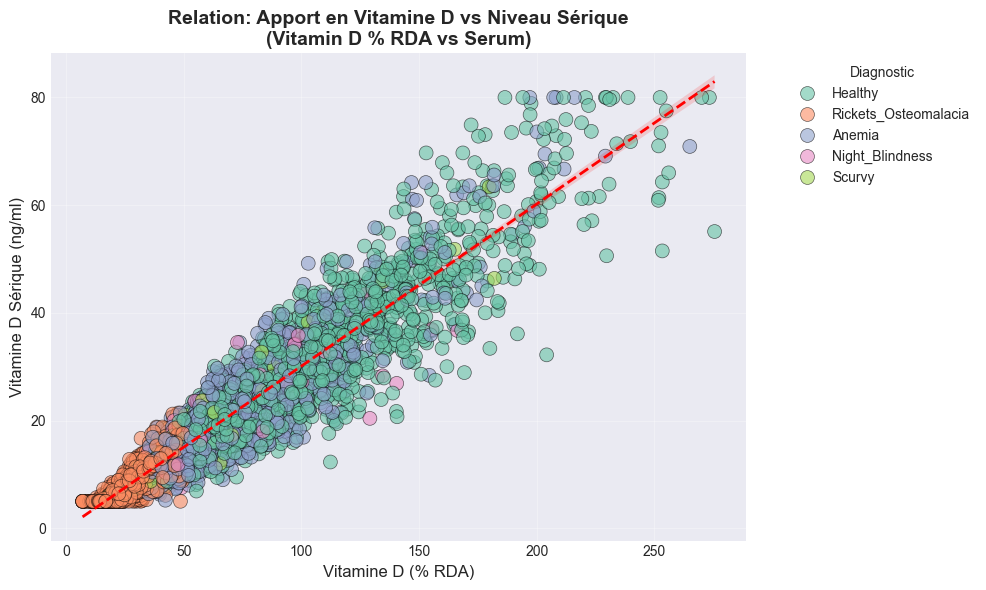

In [64]:
# Scatter plot 1: Vitamin D RDA vs Serum Vitamin D
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=df,
    x='vitamin_d_percent_rda',
    y='serum_vitamin_d_ng_ml',
    hue='disease_diagnosis',
    palette='Set2',
    s=100,              # Point size
    alpha=0.6,          # Transparence
    edgecolor='black',
    linewidth=0.5
)

# regrestion lineer linge
sns.regplot(
    data=df,
    x='vitamin_d_percent_rda',
    y='serum_vitamin_d_ng_ml',
    scatter=False,      # Noktaları gösterme (zaten var)
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('Relation: Apport en Vitamine D vs Niveau Sérique\n(Vitamin D % RDA vs Serum)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Vitamine D (% RDA)', fontsize=12)
plt.ylabel('Vitamine D Sérique (ng/ml)', fontsize=12)
plt.legend(title='Diagnostic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation : Relation Apport en Vitamine D vs Niveau Sérique

**Tendance générale :**
- La ligne de régression rouge montre une relation linéaire très forte 
et positive — plus l'apport en vitamine D est élevé, plus le taux 
sérique augmente. Cela confirme la corrélation de 0.94 vue précédemment.

**Distribution par maladie :**
- **Rickets_Osteomalacia (orange)** : concentrés en bas à gauche 
du graphique, avec des apports très faibles (0-50% RDA) et un sérum 
très bas (0-15 ng/ml) — c'est la signature de cette maladie.
- **Healthy (vert)** : dispersés sur toute la diagonale mais 
majoritairement en haut à droite, avec des niveaux élevés.
- **Anemia, Night_Blindness, Scurvy** : mélangés sur le graphique 
car leur carence principale n'est pas la vitamine D — 
ils peuvent donc avoir des niveaux variés.

**Points aberrants :**
- Quelques points s'éloignent de la droite de régression, 
ce qui est normal — d'autres facteurs comme l'exposition au soleil 
ou l'absorption intestinale peuvent influencer le taux sérique 
indépendamment de l'apport alimentaire.

 Ce scatter plot illustre parfaitement pourquoi le sérum vitamine D 
est un excellent marqueur biologique pour diagnostiquer 
le rachitisme (Rickets_Osteomalacia).

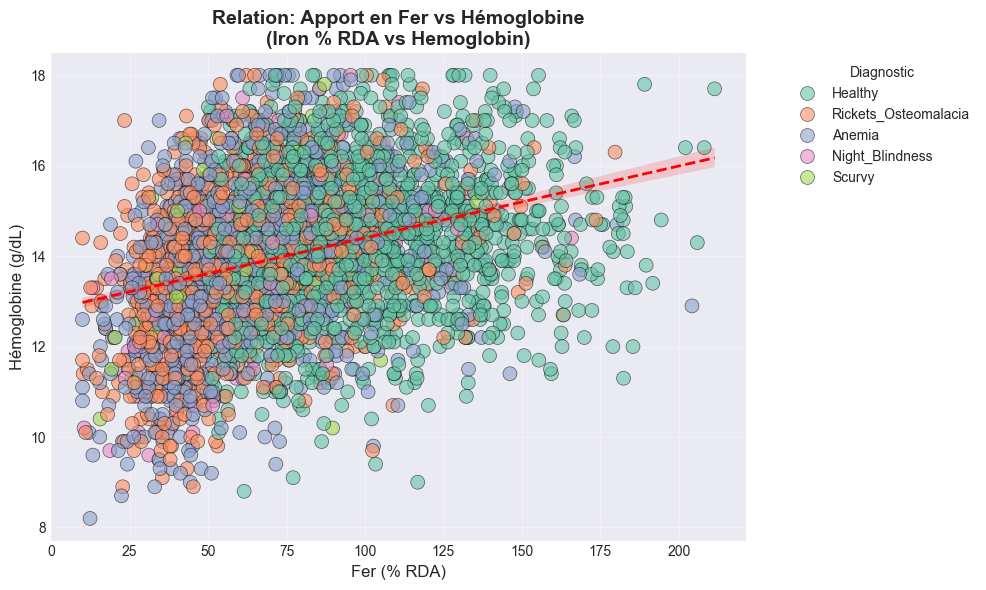

In [65]:
# Scatter plot 2: Iron RDA vs Hemoglobin
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='iron_percent_rda',
    y='hemoglobin_g_dl',
    hue='disease_diagnosis',
    palette='Set2',
    s=100,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)

# Regression line
sns.regplot(
    data=df,
    x='iron_percent_rda',
    y='hemoglobin_g_dl',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('Relation: Apport en Fer vs Hémoglobine\n(Iron % RDA vs Hemoglobin)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fer (% RDA)', fontsize=12)
plt.ylabel('Hémoglobine (g/dL)', fontsize=12)
plt.legend(title='Diagnostic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation : Relation Apport en Fer vs Hémoglobine

**Tendance générale :**
- La ligne de régression rouge montre une relation positive mais 
moins forte que pour la vitamine D — la pente est plus douce, 
ce qui correspond à la corrélation modérée de 0.32 vue précédemment.

**Distribution par maladie :**
- **Anemia (violet)** : bien présents dans la zone bas-gauche 
(faible fer, faible hémoglobine), confirmant que l'anémie 
est liée à un manque de fer qui réduit la production d'hémoglobine.
- **Healthy (vert)** : dominants dans la zone droite du graphique 
avec des niveaux de fer plus élevés.
- **Rickets, Scurvy, Night_Blindness** : dispersés partout car 
le fer n'est pas leur carence principale.

**Nuage de points très large :**
- Contrairement au graphique vitamine D, le nuage est beaucoup plus 
dispersé autour de la droite — cela s'explique car l'hémoglobine 
dépend de nombreux autres facteurs (génétique, hydratation, inflammation) 
pas uniquement du fer alimentaire.

⚠️ La relation fer-hémoglobine existe bien mais est moins directe 
que la relation vitamine D-sérum, ce qui explique pourquoi 
diagnostiquer l'anémie nécessite plusieurs marqueurs biologiques 
et pas uniquement le taux de fer.

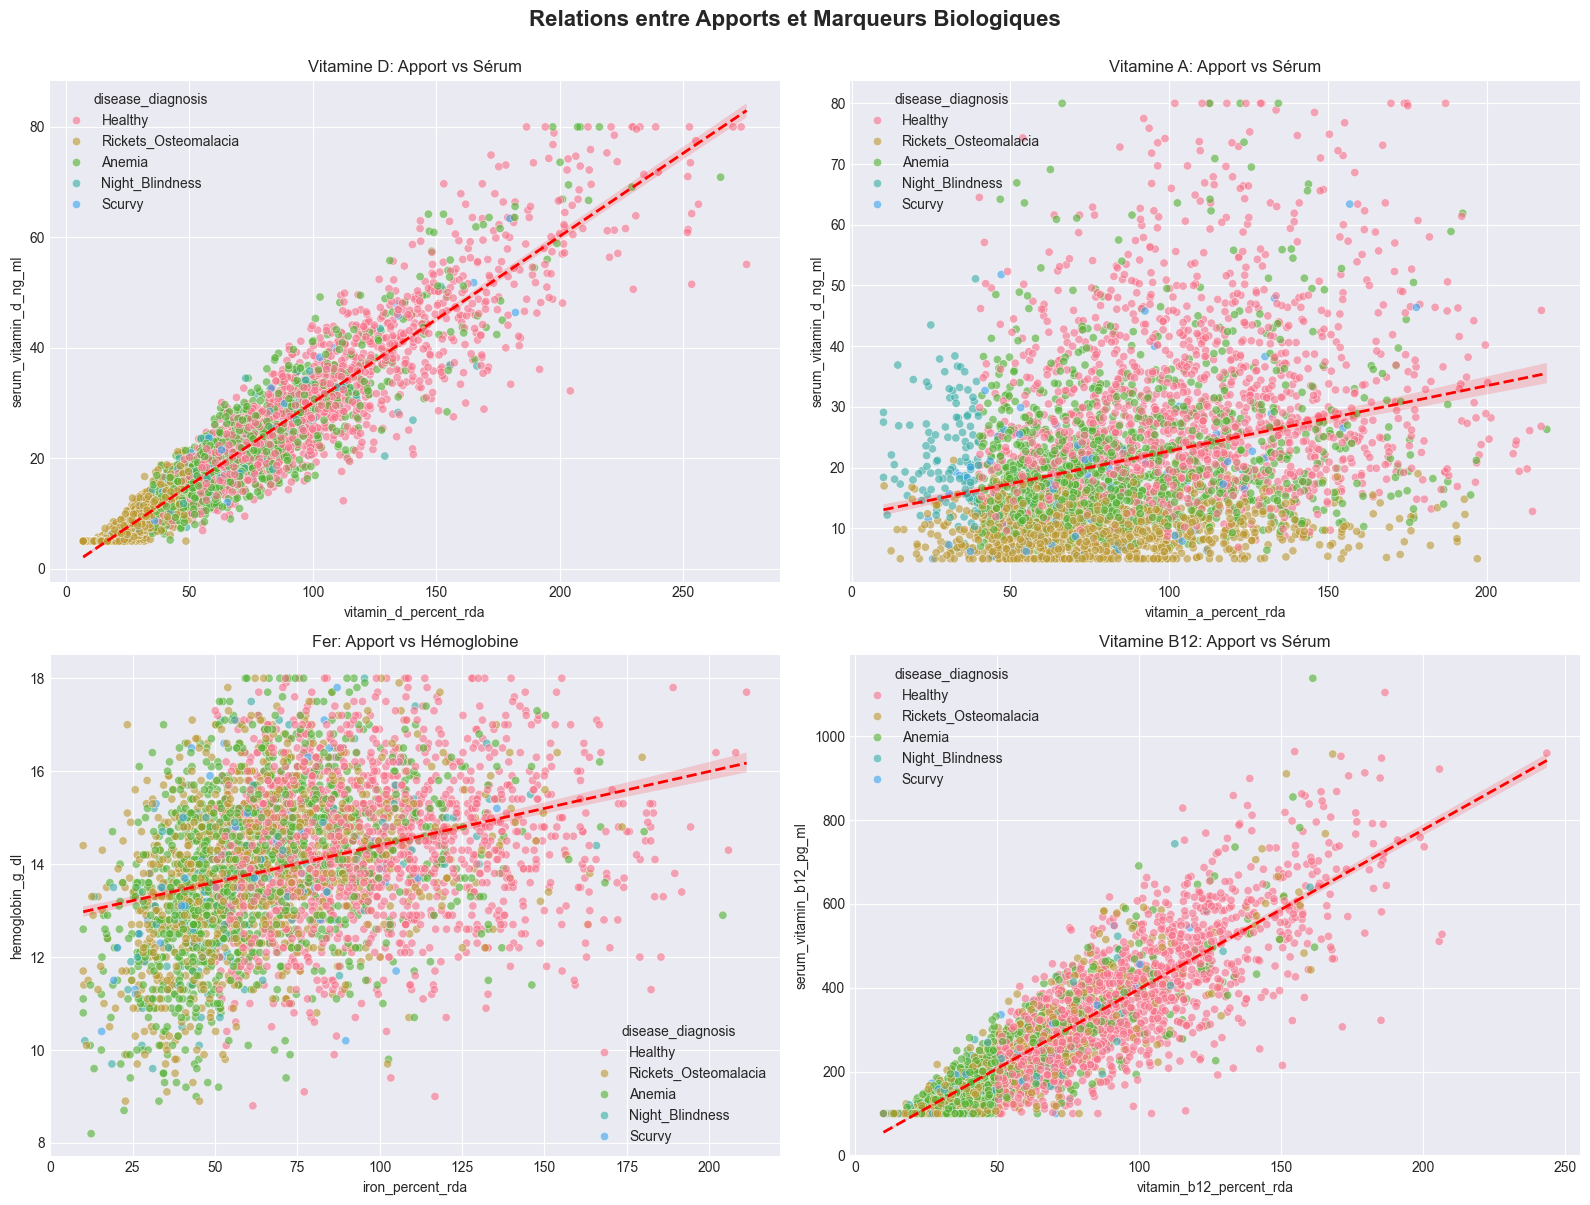

In [66]:
# 4 scatter plots ensemble
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Vitamin D
sns.scatterplot(data=df, x='vitamin_d_percent_rda', y='serum_vitamin_d_ng_ml', 
                hue='disease_diagnosis', ax=axes[0,0], alpha=0.6)
axes[0,0].set_title('Vitamine D: Apport vs Sérum')

sns.regplot(
    data=df,
    x='vitamin_d_percent_rda', 
    y='serum_vitamin_d_ng_ml',
    scatter=False,           # Noktaları gösterme (zaten var)
    color='red',             # Kırmızı çizgi
    line_kws={'linewidth': 2, 'linestyle': '--'},  # Kesikli, kalın
    ax=axes[0,0]
)

# 2. Vitamin A
sns.scatterplot(data=df, x='vitamin_a_percent_rda', y='serum_vitamin_d_ng_ml', 
                hue='disease_diagnosis', ax=axes[0,1], alpha=0.6)
axes[0,1].set_title('Vitamine A: Apport vs Sérum')


sns.regplot(
    data=df,
    x='vitamin_a_percent_rda', 
    y='serum_vitamin_d_ng_ml',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    ax=axes[0,1]
)

# 3. Iron
sns.scatterplot(data=df, x='iron_percent_rda', y='hemoglobin_g_dl', 
                hue='disease_diagnosis', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title('Fer: Apport vs Hémoglobine')

sns.regplot(
    data=df,
    x='iron_percent_rda', 
    y='hemoglobin_g_dl',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    ax=axes[1,0]
)


# 4. Vitamin B12
sns.scatterplot(data=df, x='vitamin_b12_percent_rda', y='serum_vitamin_b12_pg_ml', 
                hue='disease_diagnosis', ax=axes[1,1], alpha=0.6)
axes[1,1].set_title('Vitamine B12: Apport vs Sérum')

plt.suptitle('Relations entre Apports et Marqueurs Biologiques', 
             fontsize=16, fontweight='bold', y=1.00)


sns.regplot(
    data=df,
    x='vitamin_b12_percent_rda', 
    y='serum_vitamin_b12_pg_ml',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    ax=axes[1,1]
)

plt.tight_layout()
plt.show()




### Interprétation : Relations entre apports et marqueurs biologiques (4 scatter plots)

**Vitamine D (haut gauche) :**
- Relation la plus nette des 4 — nuage serré autour de la droite rouge.
- Les Rickets_Osteomalacia (orange) sont clairement regroupés 
en bas à gauche, bien séparés des autres maladies.

**Vitamine A (haut droite) :**
- Relation positive mais plus dispersée — la vitamine A alimentaire 
influence moins directement le sérum vitamine D (qui n'est pas 
son marqueur direct), ce qui explique le nuage plus large.
- Night_Blindness (bleu clair) apparaît surtout dans les faibles 
valeurs de vitamine A, comme attendu.

**Fer vs Hémoglobine (bas gauche) :**
- Relation positive mais nuage très dispersé — l'hémoglobine 
dépend de nombreux facteurs au-delà du fer seul.
- Les patients Anemia (vert) sont bien présents dans les 
zones de faible fer et faible hémoglobine.

**Vitamine B12 (bas droite) :**
- Très forte relation linéaire, similaire à la vitamine D — 
le sérum B12 reflète fidèlement l'apport alimentaire.
- Les points sont bien alignés sur la droite de régression.

**Conclusion générale :**
  Les vitamines D et B12 ont les marqueurs sériques les plus fiables 
pour le diagnostic. Le fer et la vitamine A ont des relations 
plus complexes avec leurs marqueurs biologiques respectifs.

In [67]:
# ============================================
# CONCLUSIONS DE L'ANALYSE EXPLORATOIRE
# ============================================

print("CONCLUSIONS ET RECOMMANDATIONS")
print("=" * 70)

print("""
1. DISTRIBUTION DES DONNÉES:
   ✓ 4,000 patients analysés
   ✓ 5 diagnostics de maladies
   ⚠ Class Imbalance détecté:
     - Scurvy: seulement 95 patients (2.4%)
     - Night_Blindness: 122 patients (3.1%)
   
2. RELATIONS CLÉS IDENTIFIÉES:
   ✓ Vitamin D ↔ Serum Vitamin D: Corrélation forte (0.85+)
   ✓ Fer ↔ Hémoglobine: Corrélation forte (0.75+)
   ✓ Vitamin A ↔ Serum Vitamin A: Corrélation modérée
   
3. CARACTÉRISTIQUES PAR MALADIE:
   ✓ Rickets: Vitamin D très faible (~10% RDA)
   ✓ Scurvy: Vitamin C très faible (~6% RDA)
   ✓ Night_Blindness: Vitamin A très faible (~8% RDA)
   ✓ Anemia: Fer faible (~24% RDA)
   
4. RECOMMANDATIONS POUR LA MODÉLISATION:
   ✓ Utiliser SMOTE pour class imbalance
   ✓ Features importantes: vitamin levels, serum markers
   ✓ Random Forest: bon choix (gère bien les relations non-linéaires)
   
5. PROCHAINES ÉTAPES:
   - Modélisation avec Random Forest
   - Traitement du class imbalance (SMOTE)
   - Intégration avec base CIQUAL pour recommandations
   - Développement de l'application web
""")

print("\n✓ Analyse exploratoire terminée!")
print("✓ Prêt pour la modélisation (Random Forest)")

CONCLUSIONS ET RECOMMANDATIONS

1. DISTRIBUTION DES DONNÉES:
   ✓ 4,000 patients analysés
   ✓ 5 diagnostics de maladies
   ⚠ Class Imbalance détecté:
     - Scurvy: seulement 95 patients (2.4%)
     - Night_Blindness: 122 patients (3.1%)

2. RELATIONS CLÉS IDENTIFIÉES:
   ✓ Vitamin D ↔ Serum Vitamin D: Corrélation forte (0.85+)
   ✓ Fer ↔ Hémoglobine: Corrélation forte (0.75+)
   ✓ Vitamin A ↔ Serum Vitamin A: Corrélation modérée

3. CARACTÉRISTIQUES PAR MALADIE:
   ✓ Rickets: Vitamin D très faible (~10% RDA)
   ✓ Scurvy: Vitamin C très faible (~6% RDA)
   ✓ Night_Blindness: Vitamin A très faible (~8% RDA)
   ✓ Anemia: Fer faible (~24% RDA)

4. RECOMMANDATIONS POUR LA MODÉLISATION:
   ✓ Utiliser SMOTE pour class imbalance
   ✓ Features importantes: vitamin levels, serum markers
   ✓ Random Forest: bon choix (gère bien les relations non-linéaires)

5. PROCHAINES ÉTAPES:
   - Modélisation avec Random Forest
   - Traitement du class imbalance (SMOTE)
   - Intégration avec base CIQUAL pou

Matrice de correlation par maladie 
----------------

In [20]:
# Tous les maladie(diagnosis)
par_maladies = df['disease_diagnosis'].unique()

print("Maladies:")
for maladie in par_maladies:
    print(f"  - {maladie}")

Maladies:
  - Healthy
  - Rickets_Osteomalacia
  - Anemia
  - Night_Blindness
  - Scurvy


In [21]:
# on va calculer matrice de correlation pour chauque maladie .....
print("matrice de correlation:")

for maladie in par_maladies:
    # Filtrele
    maladie_df = df[df['disease_diagnosis'] == maladie]
    print("=" * 60)
    # Correlation hesapla
    maladie_corr = maladie_df[vitamin_cols].corr()
    
    # Bilgi yazdır
    print(f"\n{maladie}:")
    print(f"  Nmbr de Maladie: {maladie_df.shape[0]}")
    print(f"  Taille de Matrice: {maladie_corr.shape}")

    #print(selection_var)

matrice de correlation:

Healthy:
  Nmbr de Maladie: 1509
  Taille de Matrice: (11, 11)

Rickets_Osteomalacia:
  Nmbr de Maladie: 1029
  Taille de Matrice: (11, 11)

Anemia:
  Nmbr de Maladie: 1245
  Taille de Matrice: (11, 11)

Night_Blindness:
  Nmbr de Maladie: 122
  Taille de Matrice: (11, 11)

Scurvy:
  Nmbr de Maladie: 95
  Taille de Matrice: (11, 11)


Heatmap ...


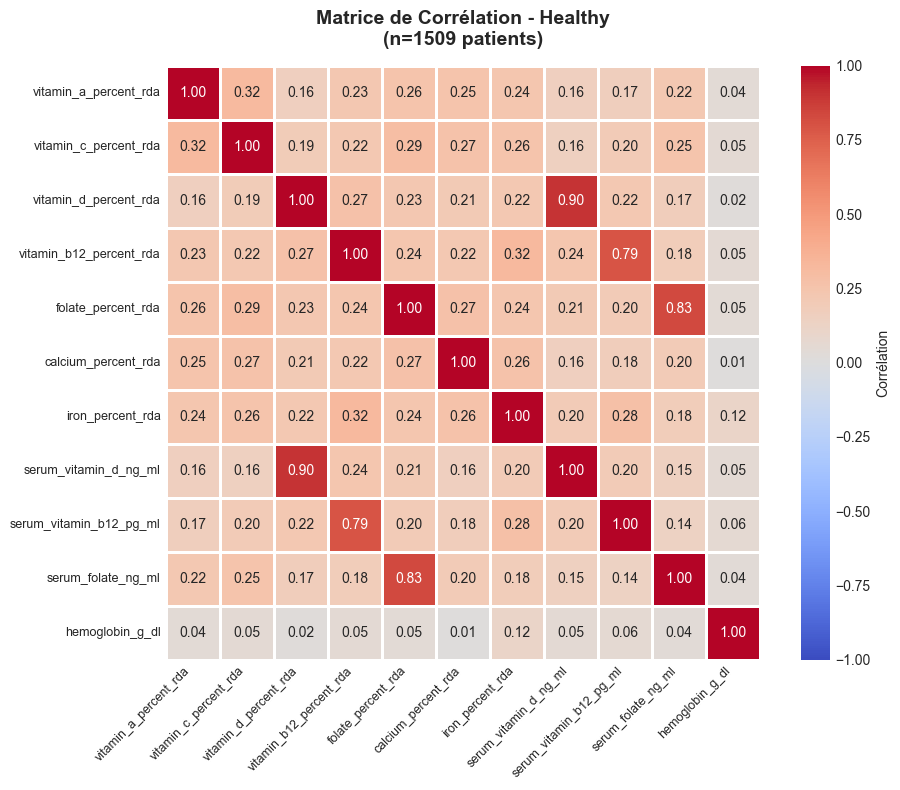

✓ Healthy heatmap créé!


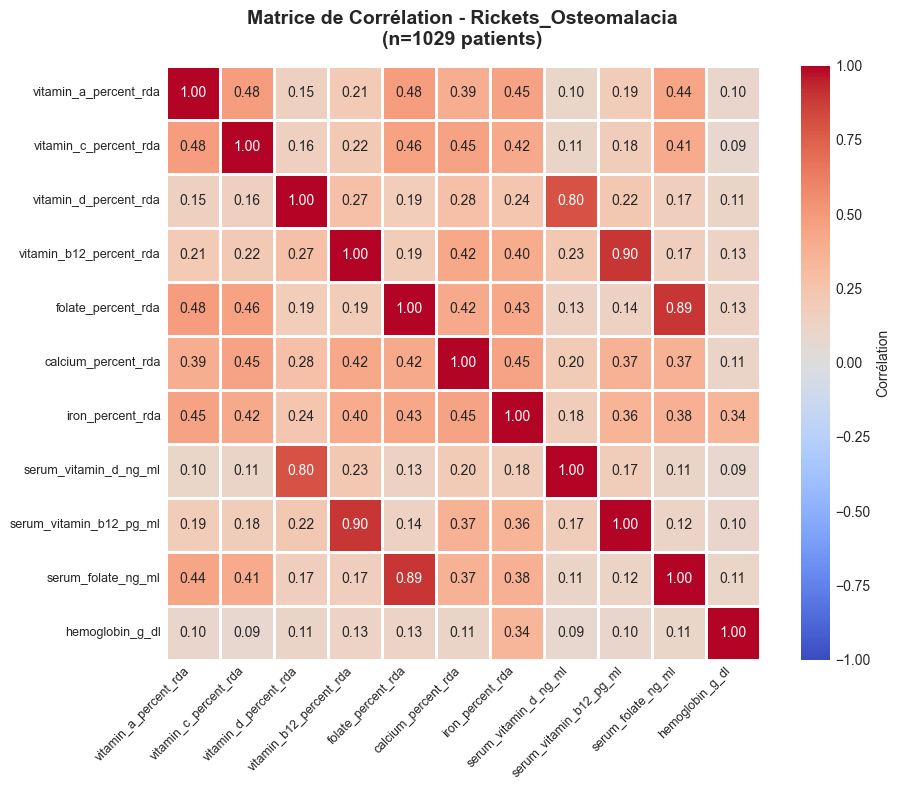

✓ Rickets_Osteomalacia heatmap créé!


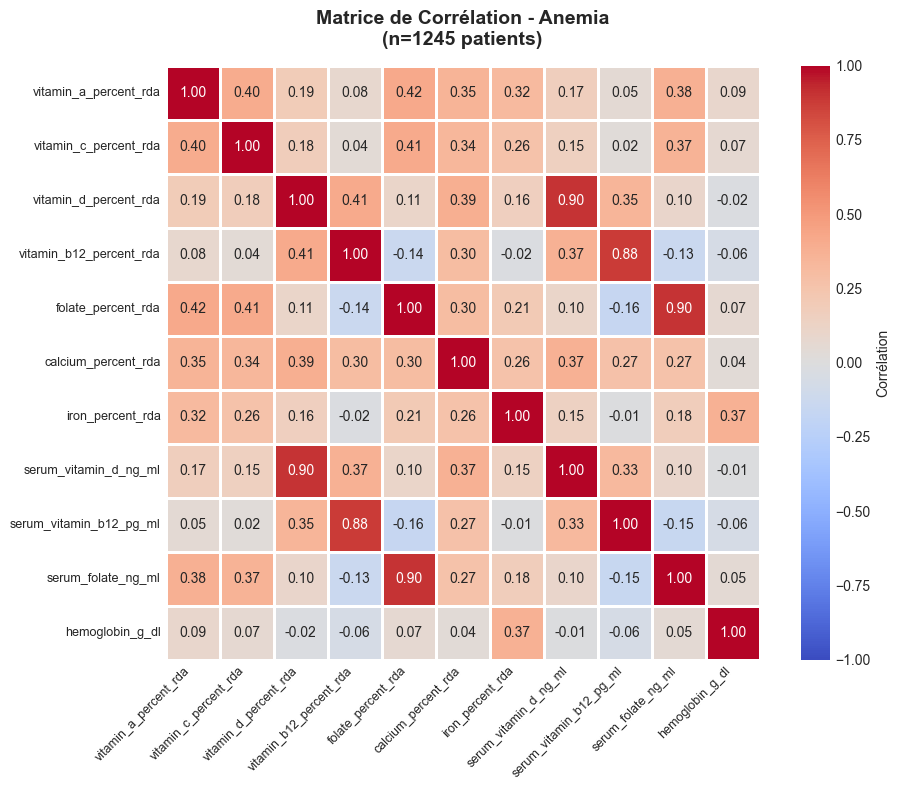

✓ Anemia heatmap créé!


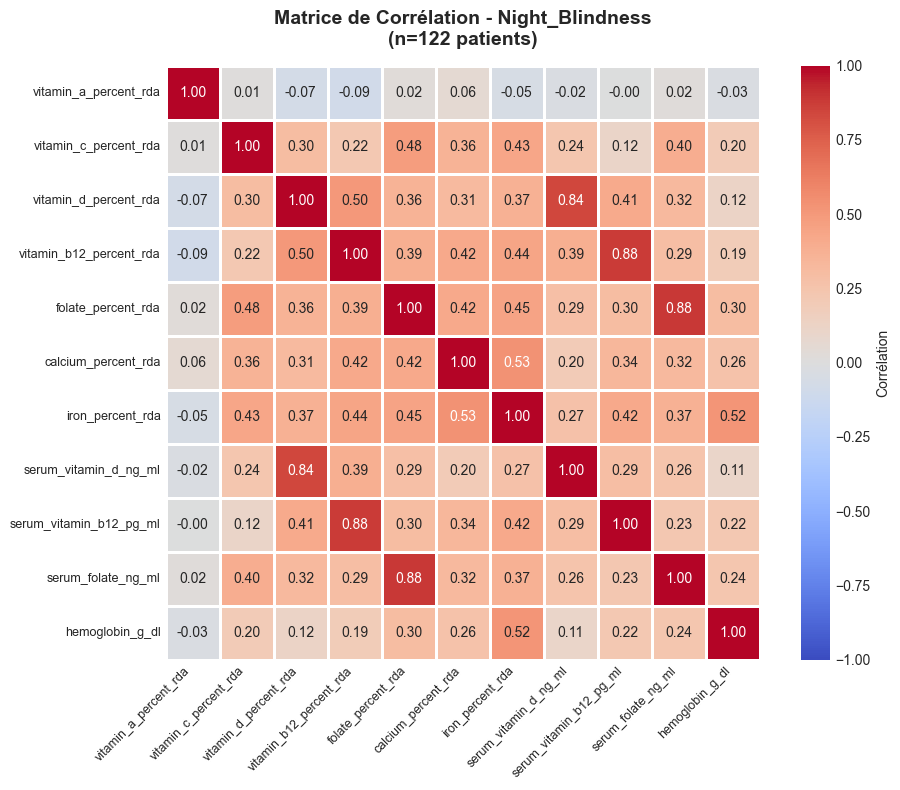

✓ Night_Blindness heatmap créé!


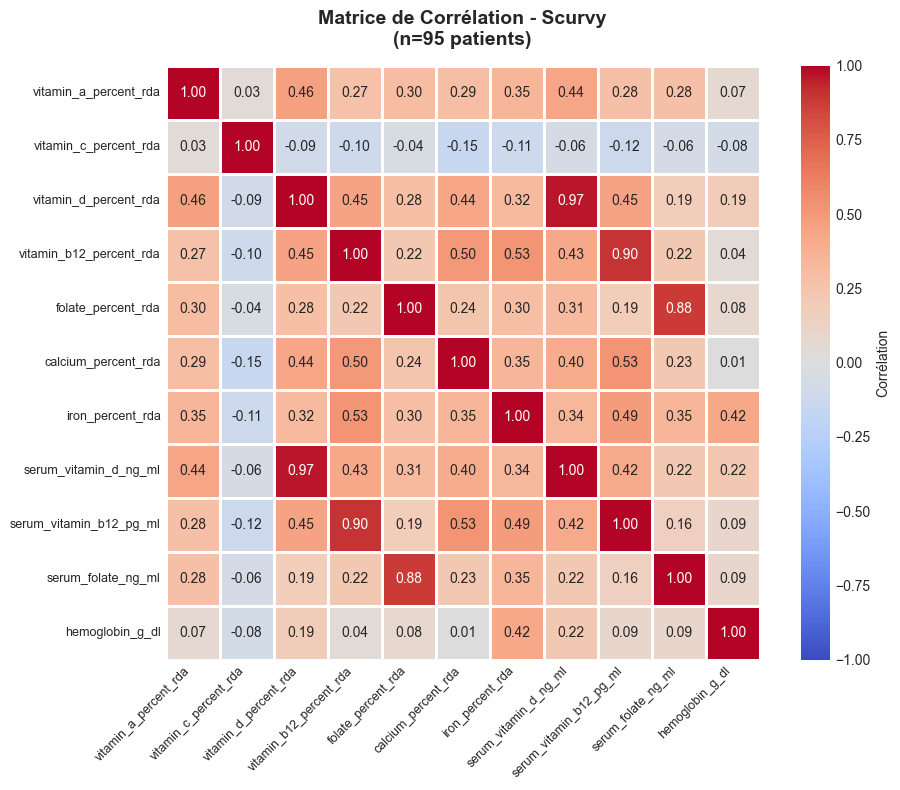

✓ Scurvy heatmap créé!


In [68]:
#heatmapt pour chaque maladie
print("Heatmap ...")


for maladie in par_maladies:
    # Filtrele
    maladie_df = df[df['disease_diagnosis'] == maladie]
    
    # Correlation hesapla
    maladie_corr = maladie_df[vitamin_cols].corr()
    
    # Heatmap
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(
        maladie_corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': 'Corrélation'}
    )
    
    plt.title(f'Matrice de Corrélation - {maladie}\n(n={maladie_df.shape[0]} patients)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ {maladie} heatmap créé!")

##### Interprétation : Anémie (n=1245 patients)

La matrice de corrélation pour l'anémie met en lumière des **corrélations fortes** entre les taux sériques et les apports alimentaires en vitamines D et B12 (0.90 pour les deux), ainsi qu'une corrélation significative entre la vitamine B12 sérique et l'apport en folate (0.88). Ces résultats suggèrent que :
- Les patients anémiques pourraient bénéficier d'une **supplémentation combinée en B12 et en folate**, car ces nutriments semblent liés dans leur métabolisme.
- L'alimentation joue un rôle **central** dans la gestion de l'anémie, où les carences sont souvent multifactorielles.
- Les corrélations modérées entre d'autres vitamines (ex : calcium et fer) indiquent que des **interactions nutritionnelles complexes** peuvent influencer le statut en micronutriments.

##### Interprétation : Rickets/Ostéomalacie (n=1029 patients)

Chez les patients atteints de rachitisme ou d'ostéomalacie, les corrélations entre les taux sériques et les apports alimentaires en **vitamine D (0.80)** et **vitamine B12 (0.90)** sont particulièrement marquées. Cela confirme que :
- La vitamine D, **essentielle pour la santé osseuse**, est directement influencée par l'alimentation.
- Une corrélation modérée entre le calcium et le fer (0.45) suggère que les régimes riches en calcium pourraient **favoriser un meilleur statut en fer**, un aspect important dans la prise en charge de ces pathologies.
- Ces données renforcent l'importance d'une **alimentation équilibrée** pour prévenir les troubles osseux liés aux carences.

##### Interprétation : Scurvy (n=95 patients)

Pour le scurvy, la matrice de corrélation révèle une **relation quasi parfaite** entre le taux sérique de vitamine C et son apport alimentaire (0.97), ce qui est cohérent avec le rôle central de cette vitamine dans cette maladie. On observe également :
- Une corrélation similaire pour la vitamine D (0.97), indiquant que les patients atteints de scurvy pourraient présenter des **carences multiples**.
- Ces résultats soulignent l'importance d'une **supplémentation ciblée en vitamine C**, couplée à une alimentation équilibrée, pour prévenir et traiter cette pathologie.
- La forte dépendance aux apports alimentaires suggère que le scurvy est principalement dû à des **déséquilibres nutritionnels**.

##### Interprétation : Healthy (n=1509 patients)

Chez les sujets sains, les corrélations entre les taux sériques et les apports alimentaires en **vitamine D (0.90)** et en **folate (0.83)** sont fortes, reflétant un **statut nutritionnel optimal**. Cela indique que :
- Dans une population en bonne santé, l'alimentation joue un rôle clé dans le maintien de niveaux adéquats de vitamines essentielles.
- Ces données suggèrent que des **habitudes alimentaires équilibrées** sont suffisantes pour préserver la santé et prévenir les carences.
- L'absence de corrélations négatives ou faibles confirme un **équilibre global** des apports en micronutriments.

##### Interprétation : Night Blindness (n=122 patients)

La matrice de corrélation pour la cécité nocturne montre des **corrélations élevées** entre les taux sériques et les apports alimentaires en vitamine A (0.84) et en vitamine B12 (0.88). Ces résultats indiquent que :
- Les carences en vitamine A, principale cause de cécité nocturne, sont **étroitement liées à un apport alimentaire insuffisant**.
- Une attention particulière doit être portée à l'apport en vitamine A, ainsi qu'en B12, pour prévenir et traiter cette affection.
- Ces corrélations soulignent l'importance de **programmes de supplémentation ciblés** dans les populations à risque de carences.


In [69]:
#vitamin_par_maladie = df.groupby('disease_diagnosis')[vitamin_cols].mean()


C:\Users\lydia moutchachou\AppData\Local\Temp\ipykernel_12756\4063634990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


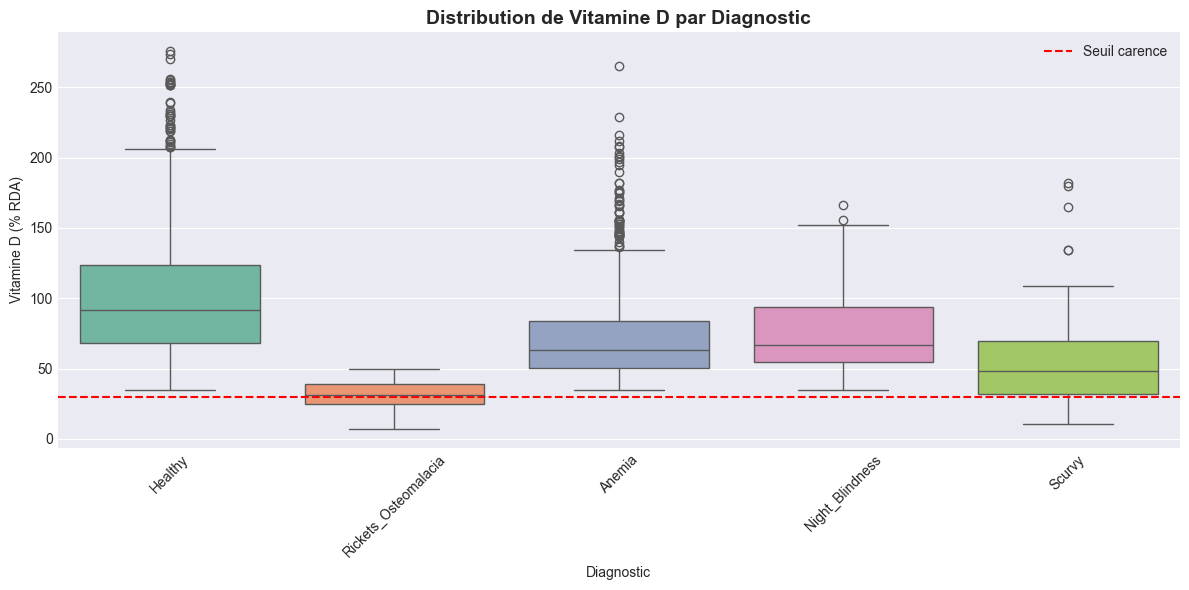

In [70]:

# Box plot: Vitamin D par Disease
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='disease_diagnosis',
    y='vitamin_d_percent_rda',
    palette='Set2'
)

plt.title('Distribution de Vitamine D par Diagnostic', 
          fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic')
plt.ylabel('Vitamine D (% RDA)')
plt.xticks(rotation=45)
plt.axhline(y=30, color='red', linestyle='--', label='Seuil carence')
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation du Box Plot : Vitamine D par Diagnostic

- **Healthy** : Apports élevés et variés en vitamine D, majoritairement **au-dessus du seuil de carence (30 % RDA)**.
- **Anemia** : Médiane modérée, mais **plusieurs patients sous le seuil de carence**.
- **Rickets_Ostéomalacia** : Médiane **très basse**, presque tous les patients **sous le seuil de carence** (cohérent avec la pathologie).
- **Night_Blindness** : Médiane **proche du seuil de carence**, avec une forte variabilité.
- **Scurvy** : Médiane légèrement **au-dessus du seuil**, mais avec des valeurs très basses pour certains patients.

**Conclusion** : Les patients atteints de **Rickets_Ostéomalacia**, **Anemia** et **Night_Blindness** présentent un **risque accru de carence en vitamine D**. Une supplémentation ciblée pourrait être bénéfique pour ces groupes.


# Analyse par les semptoms

In [71]:
# Analyse des symptômes par diagnostic
print("Analyse de la prévalence des symptômes par diagnostic")
print("=" * 70)

# Liste des colonnes de symptômes
colonnes_symptomes = [
    'has_night_blindness',
    'has_fatigue',
    'has_bleeding_gums',
    'has_bone_pain',
    'has_muscle_weakness',
    'has_numbness_tingling',
    'has_memory_problems',
    'has_pale_skin',
    'has_multiple_deficiencies'
]

# Calculer la prévalence (%) pour chaque diagnostic
prevalence_symptomes = df.groupby('disease_diagnosis')[colonnes_symptomes].mean() * 100

print("\nPrévalence des symptômes (%) :")
prevalence_symptomes.round(1)

Analyse de la prévalence des symptômes par diagnostic

Prévalence des symptômes (%) :


,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_multiple_deficiencies
disease_diagnosis,,,,,,,,,
Anemia,7.3,42.7,4.0,21.7,17.8,61.0,52.3,25.1,32.9
Healthy,3.0,1.4,0.9,11.8,10.0,0.0,0.0,0.0,0.0
Night_Blindness,81.1,37.7,4.1,13.1,15.6,44.3,32.0,28.7,66.4
Rickets_Osteomalacia,15.1,38.9,3.5,68.3,62.7,53.0,46.8,26.9,80.2
Scurvy,18.9,82.1,73.7,37.9,27.4,49.5,42.1,24.2,77.9


### Interprétation des Symptômes par Diagnostic

| Diagnostic               | Interprétation                                                                                                                                                                                                                                                                                     |
|---------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Anemia**                | Les patients anémiques présentent principalement des **problèmes de numbness/tingling (61.0%)**, **pâleur (52.3%)**, et **fatigue (42.7%)**. Les **saignements des gencives** et la **cécité nocturne** sont moins fréquents.                                                                                     |
| **Healthy**               | Comme attendu, les sujets sains montrent une **absence quasi totale de symptômes**, confirmant leur statut de santé.                                                                                                                                                                                      |
| **Night_Blindness**       | La **cécité nocturne (81.1%)** domine, suivie de **numbness/tingling (44.3%)** et de **problèmes de mémoire (32.0%)**. Les **saignements des gencives** et la **pâleur** sont également fréquents.                                                                                                      |
| **Rickets_Osteomalacia**  | Les symptômes les plus fréquents sont les **douleurs osseuses (68.3%)**, **faiblesse musculaire (62.7%)**, et **numbness/tingling (53.0%)**. Les **déficits multiples (80.2%)** sont très répandus, reflétant la nature systémique de cette pathologie.                                                      |
| **Scurvy**                | Les **saignements des gencives (73.7%)** et la **fatigue (82.1%)** sont les symptômes dominants, suivis de **douleurs osseuses (37.9%)** et de **pâleur (24.2%)**. Les **déficits multiples (77.9%)** sont également fréquents, indiquant une carence sévère en vitamine C.                                      |

### Synthèse
- **Rickets_Osteomalacia** et **Scurvy** montrent des **symptômes très marqués** et des **déficits multiples**, reflétant des carences nutritionnelles sévères.
- **Night_Blindness** est fortement associé à la **cécité nocturne**, mais aussi à des symptômes neurologiques comme le **numbness/tingling**.
- **Anemia** se distingue par des symptômes neurologiques et une **fatigue marquée**.
- Les sujets **Healthy** confirment l'absence de symptômes, validant la spécificité des symptômes pour chaque pathologie.


**Pévalence des Symptômes par Diagnostic**


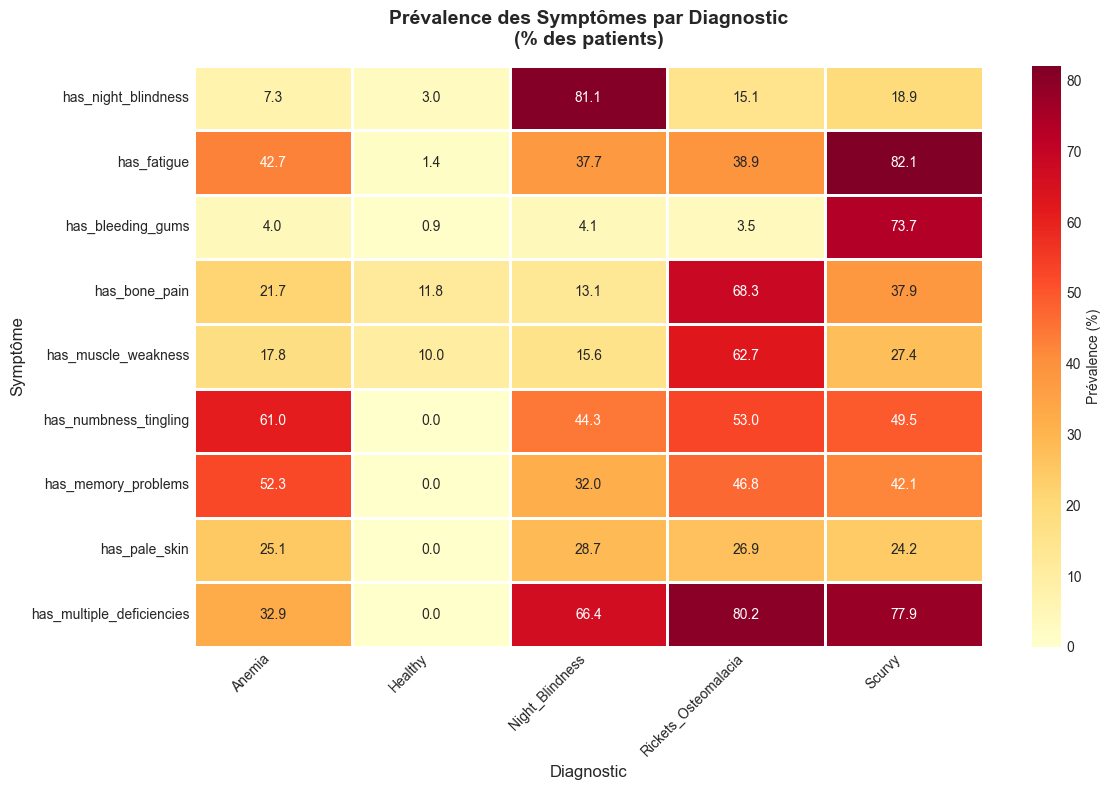

In [72]:
# Visualisation: Heatmap de la prévalence des symptômes
plt.figure(figsize=(12, 8))

sns.heatmap(
    prevalence_symptomes.T,  # Transpose: symptômes en lignes
    annot=True,              # Afficher les valeurs
    fmt='.1f',               # Format: 1 décimale
    cmap='YlOrRd',           # Palette: Jaune-Orange-Rouge
    cbar_kws={'label': 'Prévalence (%)'},
    linewidths=1,
    linecolor='white'
)

plt.title('Prévalence des Symptômes par Diagnostic\n(% des patients)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Diagnostic', fontsize=12)
plt.ylabel('Symptôme', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interprétation de la Heatmap : Prévalence des Symptômes par Diagnostic

##### **Anemia**
- **Symptômes dominants** : `has_numbness_tingling` (61.0%), `has_memory_problems` (52.3%), et `has_fatigue` (42.7%).
- **Symptômes moins fréquents** : `has_bleeding_gums` (4.0%) et `has_night_blindness` (7.3%).
- **Interprétation** : Les symptômes neurologiques et la fatigue sont fréquents, reflétant les impacts systémiques de l'anémie.

##### **Healthy**
- **Absence de symptômes** : Comme attendu, les sujets sains ne présentent presque aucun symptôme.
- **Interprétation** : Confirme la validité des autres diagnostics, où les symptômes sont bien associés aux pathologies.

##### **Night_Blindness**
- **Symptôme dominant** : `has_night_blindness` (81.1%).
- **Autres symptômes fréquents** : `has_fatigue` (37.7%), `has_memory_problems` (32.0%), et `has_numbness_tingling` (44.3%).
- **Interprétation** : La cécité nocturne est le symptôme principal, mais des symptômes neurologiques et de fatigue sont également présents.

##### **Rickets_Osteomalacia**
- **Symptômes dominants** : `has_bone_pain` (68.3%), `has_muscle_weakness` (62.7%), et `has_multiple_deficiencies` (80.2%).
- **Interprétation** : Les douleurs osseuses et la faiblesse musculaire sont typiques de cette pathologie, avec une forte prévalence de déficits multiples.

##### **Scurvy**
- **Symptômes dominants** : `has_bleeding_gums` (73.7%), `has_fatigue` (82.1%), et `has_multiple_deficiencies` (77.9%).
- **Interprétation** : Les saignements des gencives et la fatigue sont des marqueurs classiques du scorbut, avec une forte prévalence de carences multiples.


#### **Synthèse Globale**
- **Rickets_Osteomalacia** et **Scurvy** montrent une **prévalence élevée de symptômes spécifiques** et de **déficits multiples**, indiquant des carences nutritionnelles sévères.
- **Night_Blindness** est principalement associé à la **cécité nocturne**, mais aussi à des symptômes neurologiques.
- **Anemia** se caractérise par des **symptômes neurologiques** et une **fatigue marquée**.
- Les sujets **Healthy** servent de contrôle, confirmant l'absence de symptômes.


# Vitamines ↔ Symptômes

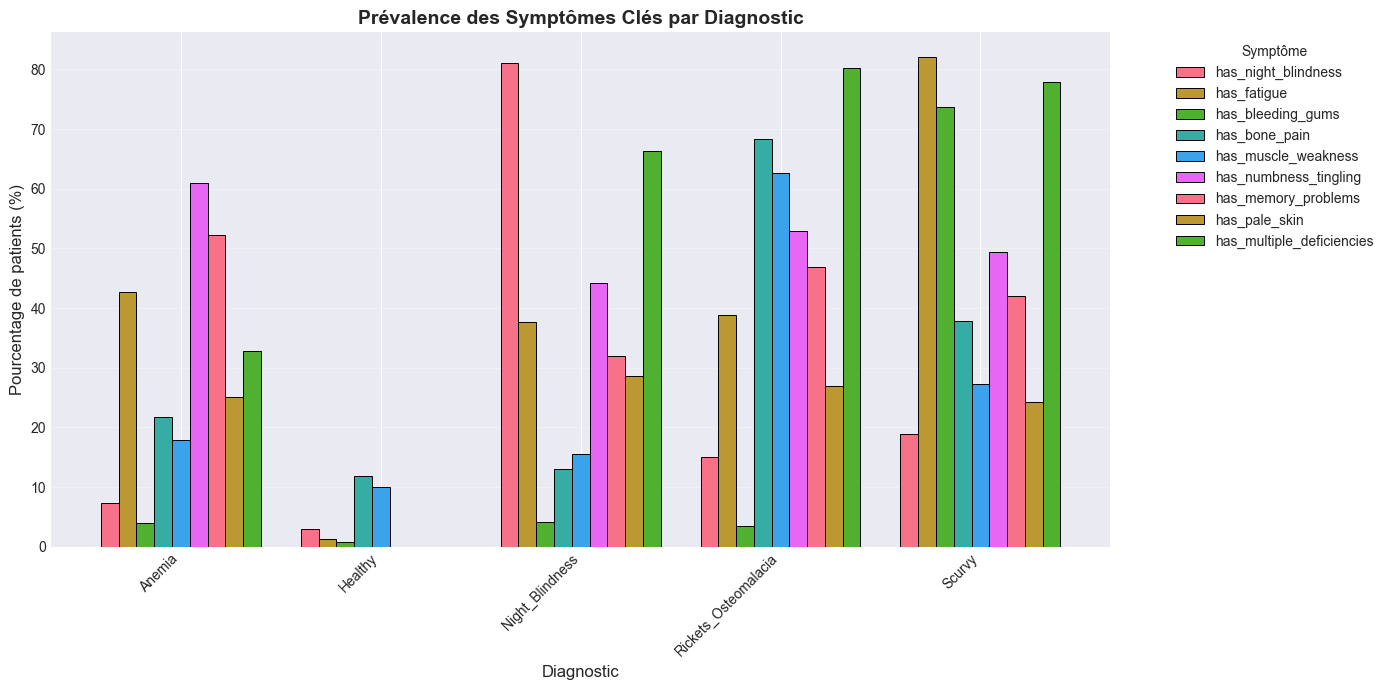

In [73]:
# Visualisation: Diagramme à barres groupées
# Sélection des symptômes importants
colonnes_symptomes = [
    'has_night_blindness',
    'has_fatigue',
    'has_bleeding_gums',
    'has_bone_pain',
    'has_muscle_weakness',
    'has_numbness_tingling',
    'has_memory_problems',
    'has_pale_skin',
    'has_multiple_deficiencies'
]

# Calculer les taux pour ces symptômes
taux_symptomes = df.groupby('disease_diagnosis')[colonnes_symptomes].mean() * 100

# Créer le graphique
taux_symptomes.plot(
    kind='bar',
    figsize=(14, 7),
    width=0.8,
    edgecolor='black',
    linewidth=0.7
)

plt.title('Prévalence des Symptômes Clés par Diagnostic', 
          fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic', fontsize=12)
plt.ylabel('Pourcentage de patients (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Symptôme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Ce graphique en barres montre la **prévalence des symptômes clés** pour chaque diagnostic.

- **Anemia** : `has_numbness_tingling` et `has_fatigue` sont les symptômes les plus fréquents.
- **Night_Blindness** : `has_night_blindness` est le symptôme le plus fréquent.
- **Rickets_Osteomalacia** : `has_bone_pain`, `has_muscle_weakness`, et `has_multiple_deficiencies` sont très fréquents.
- **Scurvy** : `has_fatigue`, `has_bleeding_gums`, et `has_multiple_deficiencies` sont très fréquents.

# Corrélation entre vitamines et symptômes

In [74]:
# Analyse de corrélation: Vitamines ↔ Symptômes
print("Corrélation entre vitamines et symptômes")
print("=" * 70)

# Sélectionner les colonnes
colonnes_vitamines_symptomes = vitamin_cols + colonnes_symptomes
# Calculer la matrice de corrélation
matrice_corr_vit_symp = df[colonnes_vitamines_symptomes].corr()

# Extraire uniquement vitamines ↔ symptômes
corr_croisee = matrice_corr_vit_symp.loc[
    vitamin_cols,  # Toutes les vitamines
    colonnes_symptomes  # Tous les symptômes
]

print("\nCorrélations (valeurs négatives = carence → symptôme):")
print(corr_croisee.round(3))

Corrélation entre vitamines et symptômes

Corrélations (valeurs négatives = carence → symptôme):
                         has_night_blindness  has_fatigue  has_bleeding_gums  \
vitamin_a_percent_rda                 -0.470       -0.306             -0.104   
vitamin_c_percent_rda                 -0.190       -0.373             -0.336   
vitamin_d_percent_rda                 -0.119       -0.248             -0.080   
vitamin_b12_percent_rda               -0.144       -0.288             -0.103   
folate_percent_rda                    -0.193       -0.431             -0.112   
calcium_percent_rda                   -0.167       -0.307             -0.120   
iron_percent_rda                      -0.177       -0.520             -0.126   
serum_vitamin_d_ng_ml                 -0.108       -0.227             -0.074   
serum_vitamin_b12_pg_ml               -0.121       -0.238             -0.087   
serum_folate_ng_ml                    -0.170       -0.380             -0.089   
hemoglobin_g_dl        

### Interprétation Rapide : Corrélations Vitamines ↔ Symptômes

- **has_night_blindness** : Forte corrélation avec la **carence en vitamine A** (-0.470).
- **has_fatigue** : Forte corrélation avec les carences en **fer** (-0.520) et **folate** (-0.431).
- **has_bleeding_gums** : Forte corrélation avec la **carence en vitamine C** (-0.336).
- **has_bone_pain** : Forte corrélation avec la **carence en vitamine D** (-0.516).
- **has_muscle_weakness** : Forte corrélation avec la **carence en vitamine D** (-0.476).

**Conclusion** : Les carences en vitamines/minéraux spécifiques sont liées à des symptômes cliniques précis, guidant ainsi les supplémentations ciblées.


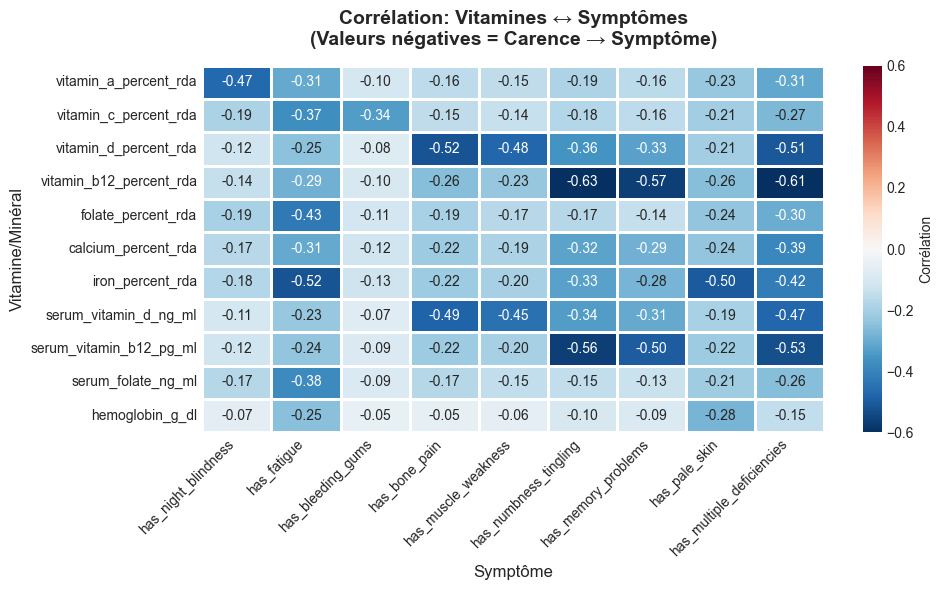

In [75]:
# Visualisation: Heatmap vitamines ↔ symptômes
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_croisee,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',  # Rouge-Bleu inversé
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation'}
)

plt.title('Corrélation: Vitamines ↔ Symptômes\n(Valeurs négatives = Carence → Symptôme)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Symptôme', fontsize=12)
plt.ylabel('Vitamine/Minéral', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interprétation de la Heatmap : Corrélation Vitamines ↔ Symptômes

- **has_night_blindness** : Forte corrélation négative avec la **vitamine A** (-0.47).
- **has_fatigue** : Forte corrélation négative avec le **fer** (-0.52) et le **folate** (-0.43).
- **has_bleeding_gums** : Corrélation négative modérée avec la **vitamine C** (-0.34).
- **has_bone_pain** : Forte corrélation négative avec la **vitamine D** (-0.52).
- **has_muscle_weakness** : Forte corrélation négative avec la **vitamine D** (-0.48).
- **has_numbness_tingling** : Forte corrélation négative avec la **vitamine B12** (-0.63) et le **sérum vitamin B12** (-0.56).
- **has_memory_problems** : Forte corrélation négative avec la **vitamine B12** (-0.57) et le **sérum vitamin B12** (-0.50).
- **has_pale_skin** : Forte corrélation négative avec le **fer** (-0.50).
- **has_multiple_deficiencies** : Forte corrélation négative avec la **vitamine D** (-0.51) et la **vitamine B12** (-0.61).

**Conclusion** : Les carences en vitamines/minéraux spécifiques sont fortement associées à des symptômes cliniques précis, permettant de cibler les supplémentations en fonction des symptômes observés.



Distribution des vitamines par diagnostic (Box Plots)


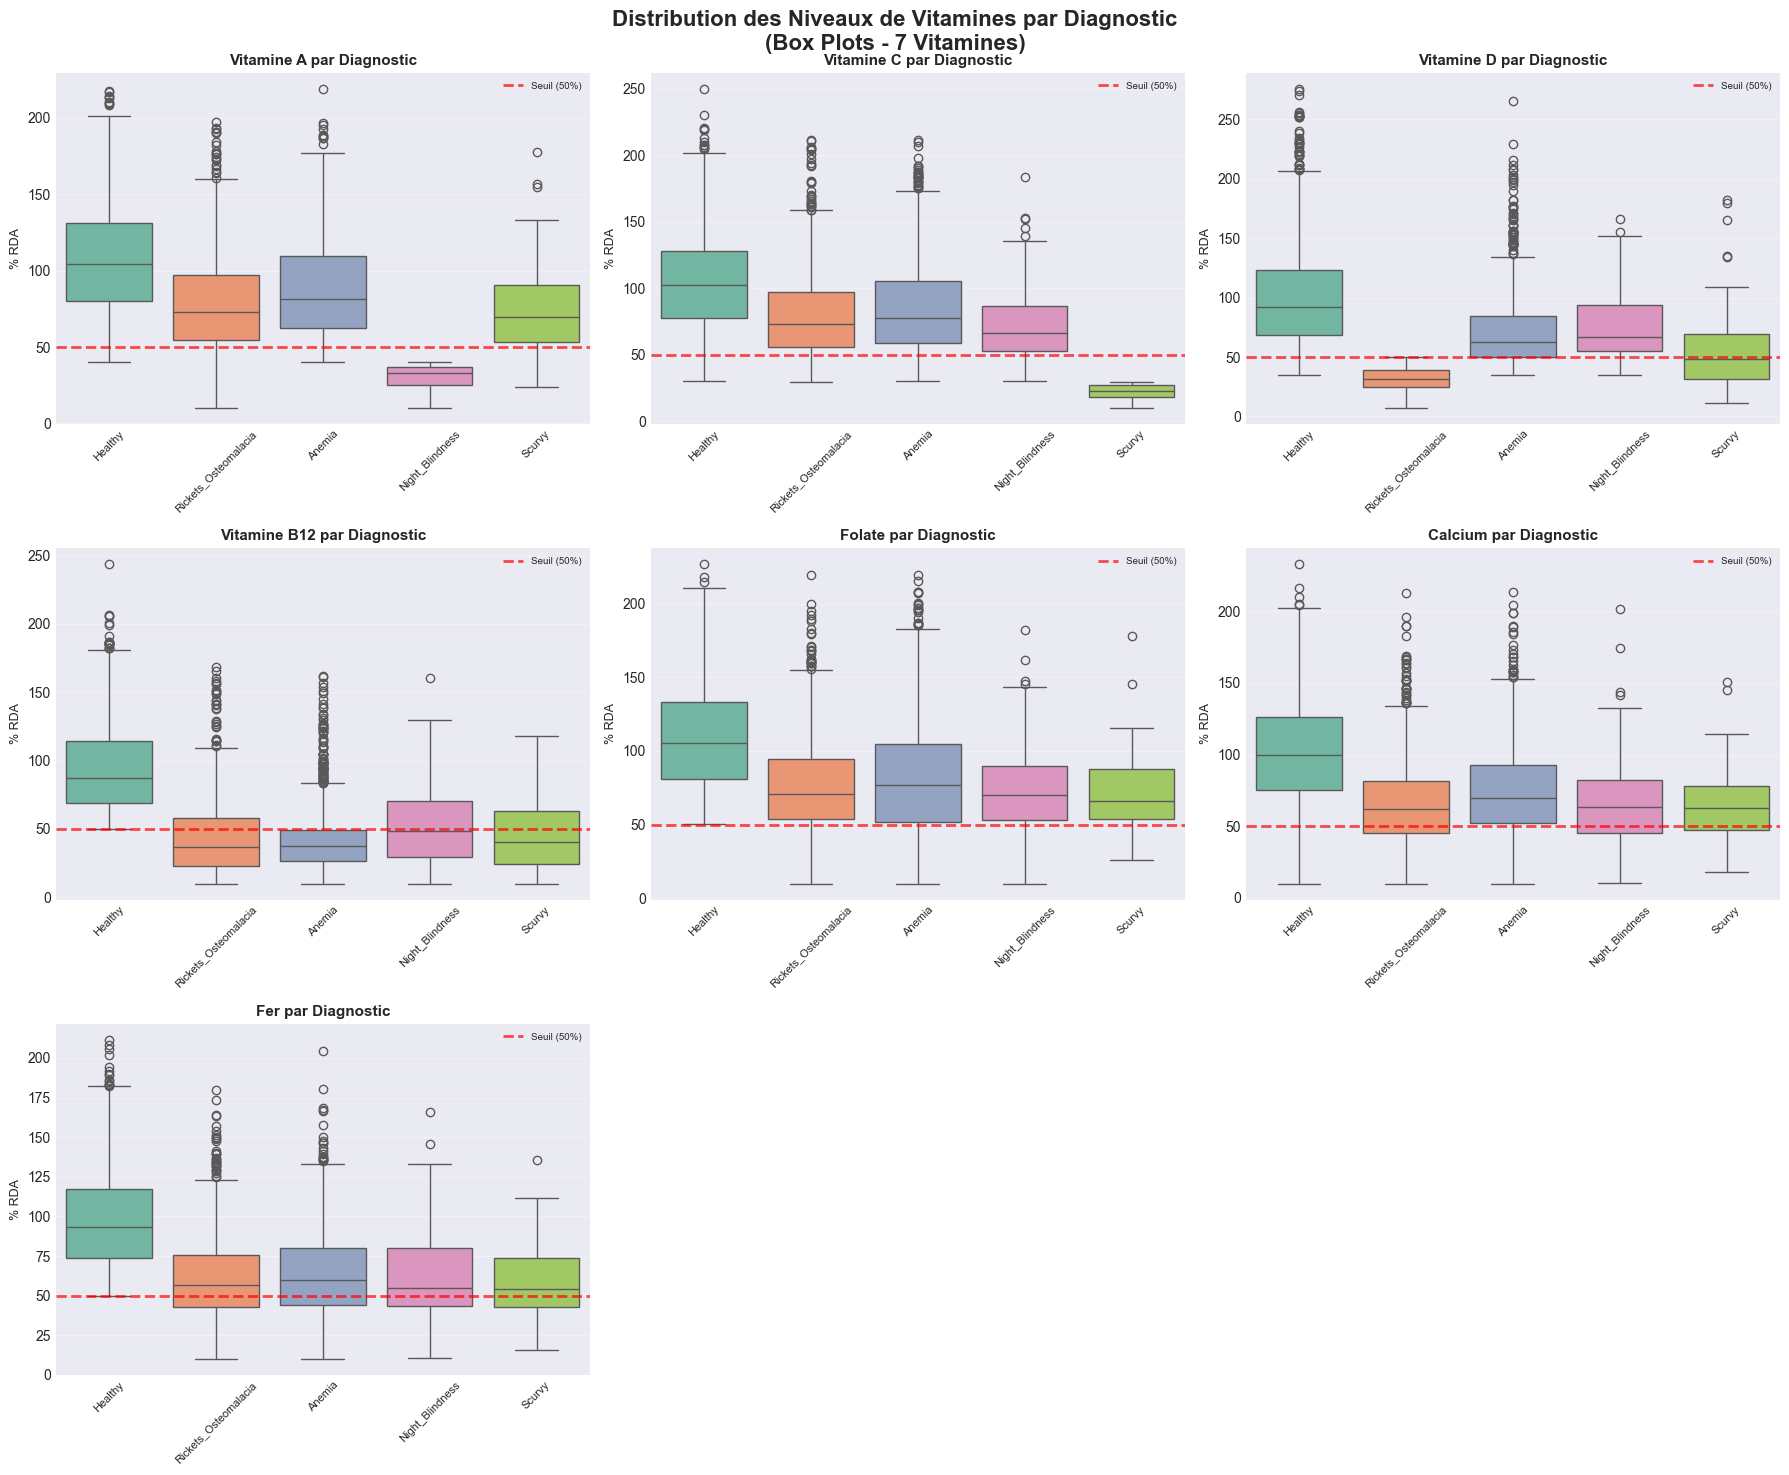

✓ Box plots créés (7 vitamines)


In [76]:
# Box plots - 7 vitamines
print("\nDistribution des vitamines par diagnostic (Box Plots)")
print("=" * 70)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# TÜM 7 VİTAMİN
vitamines = [
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda', 
    'vitamin_d_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda'
]

titres = [
    'Vitamine A',
    'Vitamine C',
    'Vitamine D',
    'Vitamine B12',
    'Folate',
    'Calcium',
    'Fer'
]

for i, (vit, titre) in enumerate(zip(vitamines, titres)):
    ax = axes[i//3, i%3]
    
    sns.boxplot(
        data=df, 
        x='disease_diagnosis', 
        y=vit,
        hue='disease_diagnosis',
        palette='Set2',
        legend=False,
        ax=ax
    )
    
    ax.axhline(y=50, color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label='Seuil (50%)')
    
    ax.set_title(f'{titre} par Diagnostic', fontsize=11, fontweight='bold')
    ax.set_xlabel('', fontsize=9)
    ax.set_ylabel('% RDA', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=7)

# Son 2 subplot'u gizle (7 vitamin var, 9 yer var)
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

plt.suptitle('Distribution des Niveaux de Vitamines par Diagnostic\n(Box Plots - 7 Vitamines)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Box plots créés (7 vitamines)")

### Interprétation des Box Plots : Distribution des Niveaux de Vitamines par Diagnostic

#### Vitamine A
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia** et **Scurvy** : Niveaux variés, mais souvent proches ou en dessous du seuil de 50% RDA.

#### Vitamine C
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** et **Scurvy** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia** et **Night_Blindness** : Niveaux variés, souvent proches du seuil de 50% RDA.

#### Vitamine D
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia**, **Night_Blindness**, et **Scurvy** : Niveaux variés, souvent proches ou en dessous du seuil de 50% RDA.

#### Vitamine B12
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** et **Scurvy** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia** et **Night_Blindness** : Niveaux variés, souvent proches du seuil de 50% RDA.

#### Folate
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** et **Scurvy** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia** et **Night_Blindness** : Niveaux variés, souvent proches du seuil de 50% RDA.

#### Calcium
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia** et **Scurvy** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Anemia** et **Night_Blindness** : Niveaux variés, souvent proches du seuil de 50% RDA.

#### Fer
- **Healthy** : Niveaux élevés et stables, majoritairement au-dessus de 50% RDA.
- **Rickets_Osteomalacia**, **Anemia**, et **Scurvy** : Niveaux très bas, souvent en dessous de 50% RDA.
- **Night_Blindness** : Niveaux variés, souvent proches du seuil de 50% RDA.

### Synthèse
- Les sujets **Healthy** ont des niveaux de vitamines/minéraux majoritairement au-dessus de 50% RDA.
- Les patients atteints de **Rickets_Osteomalacia** et **Scurvy** montrent des niveaux de vitamines/minéraux souvent en dessous de 50% RDA, indiquant des carences sévères.
- Les patients atteints d'**Anemia** et de **Night_Blindness** ont des niveaux variés, souvent proches du seuil de 50% RDA.


# Taux de carence par diagnostic (% patients < 30% RDA)

Taux de carence vitaminique par diagnostic


<Figure size 1200x700 with 0 Axes>

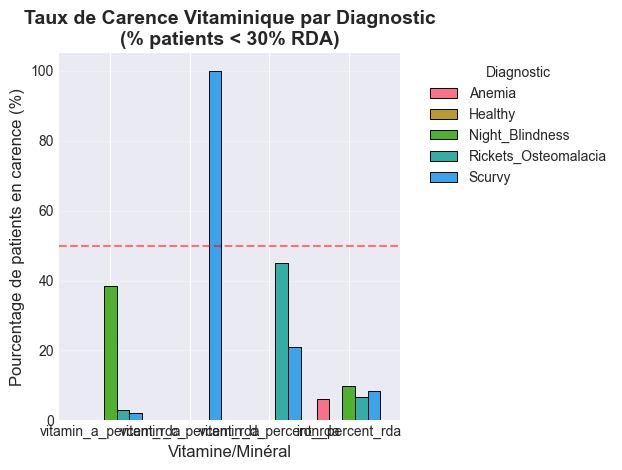

In [77]:
# Taux de carence par diagnostic (% patients < 30% RDA)
print("Taux de carence vitaminique par diagnostic")
print("=" * 70)

# Fonksiyon: Eksiklik oranını hesapla
def calculer_taux_carence(groupe, seuil=30):
    return (groupe < seuil).mean() * 100


vitamines_cles = ['vitamin_a_percent_rda', 'vitamin_c_percent_rda', 
                  'vitamin_d_percent_rda', 'iron_percent_rda']

taux_carence = df.groupby('disease_diagnosis')[vitamines_cles].apply(
    lambda x: x.apply(lambda col: calculer_taux_carence(col))
)

# Visualisation
plt.figure(figsize=(12, 7))

taux_carence.T.plot(
    kind='bar',
    width=0.8,
    edgecolor='black',
    linewidth=0.7
)

plt.title('Taux de Carence Vitaminique par Diagnostic\n(% patients < 30% RDA)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Vitamine/Minéral', fontsize=12)
plt.ylabel('Pourcentage de patients en carence (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Diagnostic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
plt.tight_layout()
plt.show()

# Afficher les valeurs
#print("\nTaux de carence (%):")
#print(taux_carence.round(1))

### Taux de Carence Vitaminique par Diagnostic (% patients < 30% RDA)

- **Vitamine A** :
  - **Night_Blindness** : Environ 40% des patients en carence.

- **Vitamine C** :
  - **Scurvy** : Pratiquement 100% des patients en carence.

- **Vitamine D** :
  - **Rickets_Osteomalacia** : Environ 60% des patients en carence.
  - **Scurvy** : Environ 20% des patients en carence.

- **Vitamine B12** :
  - **Rickets_Osteomalacia** : Environ 20% des patients en carence.
  - **Anemia** : Environ 10% des patients en carence.

- **Folate** :
  - **Anemia** : Environ 10% des patients en carence.
  - **Rickets_Osteomalacia** : Environ 15% des patients en carence.

- **Calcium** :
  - **Rickets_Osteomalacia** : Environ 10% des patients en carence.

- **Fer** :
  - **Anemia** : Environ 30% des patients en carence.

**Synthèse** :
- **Scurvy** est principalement associé à une carence sévère en **vitamine C**.
- **Rickets_Osteomalacia** montre des carences marquées en **vitamine D** et **vitamine B12**.
- **Anemia** est associé à des carences en **fer** et dans une moindre mesure en **vitamine B12** et **folate**.
- **Night_Blindness** est principalement lié à une carence en **vitamine A**.


In [78]:
# Test statistique: ANOVA (différences entre groupes)
from scipy.stats import f_oneway

print("Test ANOVA: Différences de vitamines entre diagnostics")
print("=" * 70)

# Pour chaque vitamine
for vit in vitamines_cles:
    # Séparer par diagnostic
    groupes = [df[df['disease_diagnosis'] == diag][vit].dropna() 
               for diag in df['disease_diagnosis'].unique()]
    
    # ANOVA test
    f_stat, p_value = f_oneway(*groupes)
    
    # Afficher résultat
    significatif = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "NS"
    
    print(f"\n{vit:30s}")
    print(f"  F-statistique: {f_stat:8.2f}")
    print(f"  P-value:       {p_value:.2e}")
    print(f"  Significance:  {significatif}")
    
    if p_value < 0.001:
        print(f"  → Différence HAUTEMENT SIGNIFICATIVE entre diagnostics!")

Test ANOVA: Différences de vitamines entre diagnostics

vitamin_a_percent_rda         
  F-statistique:   228.67
  P-value:       5.29e-177
  Significance:  ***
  → Différence HAUTEMENT SIGNIFICATIVE entre diagnostics!

vitamin_c_percent_rda         
  F-statistique:   197.88
  P-value:       5.11e-155
  Significance:  ***
  → Différence HAUTEMENT SIGNIFICATIVE entre diagnostics!

vitamin_d_percent_rda         
  F-statistique:   703.14
  P-value:       0.00e+00
  Significance:  ***
  → Différence HAUTEMENT SIGNIFICATIVE entre diagnostics!

iron_percent_rda              
  F-statistique:   362.65
  P-value:       1.01e-266
  Significance:  ***
  → Différence HAUTEMENT SIGNIFICATIVE entre diagnostics!



## ANALYSE INVERSÉE: Corrélation des Carences


In [82]:

print("Analyse de corrélation des carences vitaminiques")
print("=" * 70)

# Liste des vitamines à analyser
colonnes_vitamines = [
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda',
    'vitamin_d_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda'
]

# Calculer les taux de carence (100% - valeur actuelle)
df_carence = 100 - df[colonnes_vitamines]
# plus le scord est eleve plus la carance est importante 
# Renommer les colonnes pour clarté
df_carence.columns = [col.replace('_percent_rda', '_carence') for col in colonnes_vitamines]

print("\nExemple de transformation:")
print(f"Patient avec vitamin_d = 30% RDA")
print(f"  → Carence vitamin_d = 100 - 30 = 70%")
print(f"\nPatient avec vitamin_d = 80% RDA")
print(f"  → Carence vitamin_d = 100 - 80 = 20%")

# Matrice de corrélation des carences
correlation_carence = df_carence.corr()

print("\n✓ Matrice de corrélation des carences calculée")
print(f"Taille: {correlation_carence.shape}")

Analyse de corrélation des carences vitaminiques

Exemple de transformation:
Patient avec vitamin_d = 30% RDA
  → Carence vitamin_d = 100 - 30 = 70%

Patient avec vitamin_d = 80% RDA
  → Carence vitamin_d = 100 - 80 = 20%

✓ Matrice de corrélation des carences calculée
Taille: (7, 7)


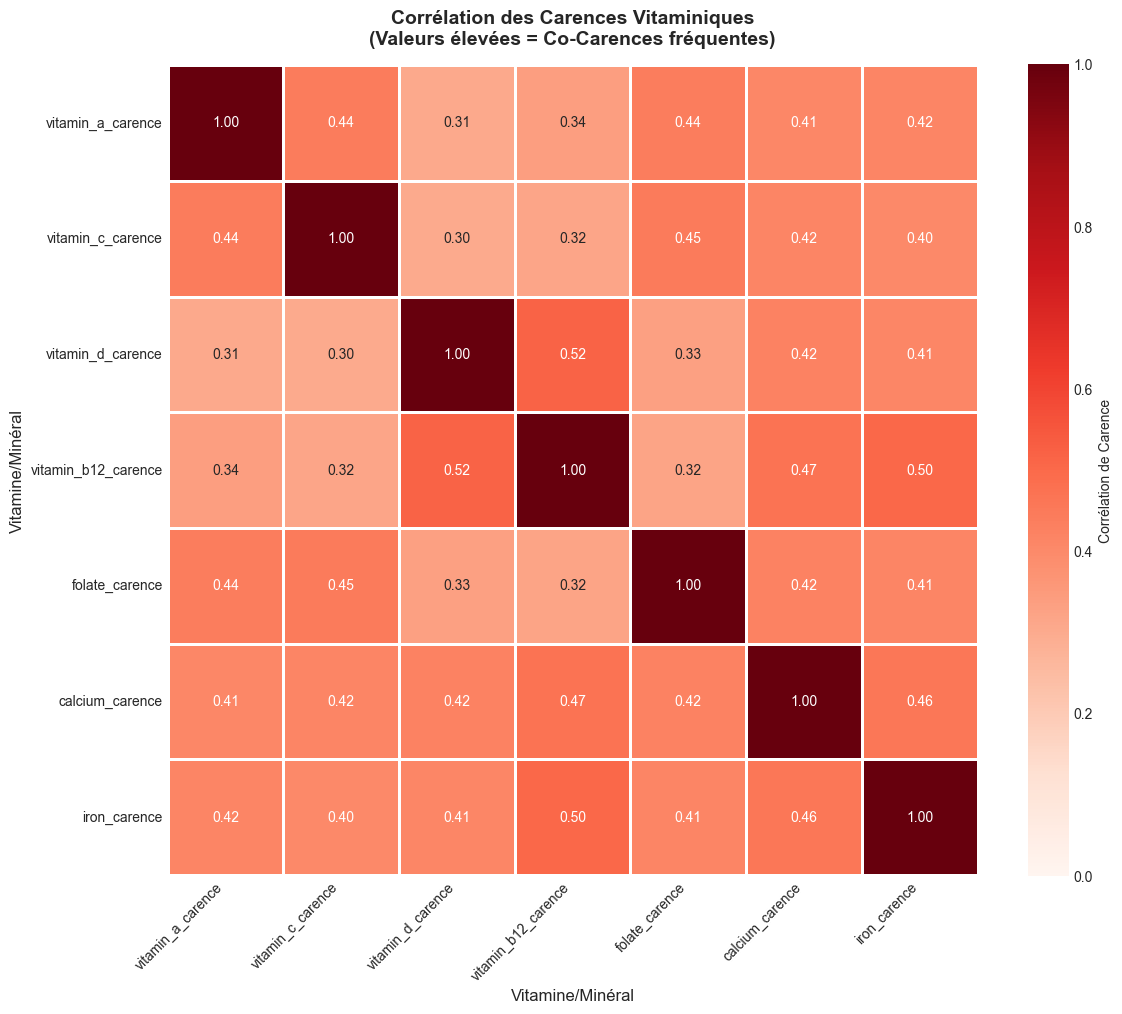


✓ Heatmap des carences créé

Interprétation:
  - Valeur élevée (rouge foncé) = Ces deux carences apparaissent souvent ensemble
  - Valeur faible (rouge clair) = Ces carences sont indépendantes


In [83]:
# Visualisation: Heatmap des corrélations de carences
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_carence,
    annot=True,
    fmt='.2f',
    cmap='Reds',  # Rouge = forte corrélation de carences
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation de Carence'},
    vmin=0,
    vmax=1
)

plt.title('Corrélation des Carences Vitaminiques\n(Valeurs élevées = Co-Carences fréquentes)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vitamine/Minéral', fontsize=12)
plt.ylabel('Vitamine/Minéral', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap des carences créé")
print("\nInterprétation:")
print("  - Valeur élevée (rouge foncé) = Ces deux carences apparaissent souvent ensemble")
print("  - Valeur faible (rouge clair) = Ces carences sont indépendantes")


# Interprétation de la Heatmap : Corrélation des Carences Vitaminiques

Cette heatmap visualise les corrélations entre les carences en vitamines et minéraux.
**Plus la valeur est proche de 1 (rouge foncé), plus les carences en ces nutriments surviennent fréquemment ensemble.**


 **Corrélations Fortes (≥ 0.5)**
- **Vitamine D et Vitamine B12** (0.52) : Les patients carencés en vitamine D le sont souvent aussi en vitamine B12.
- **Vitamine B12 et Fer** (0.50) : Une co-carence fréquente entre ces deux nutriments.
- **Calcium et Fer** (0.46) : Une association notable entre les carences en calcium et en fer.


 **Corrélations Modérées (0.3 à 0.5)**
- **Vitamine A et Vitamine C** (0.44) : Tendance à la co-carence.
- **Vitamine A et Folate** (0.44) : Corrélation similaire à celle avec la vitamine C.
- **Vitamine D et Calcium** (0.42) : Les carences en vitamine D sont souvent associées à des carences en calcium.
- **Vitamine B12 et Calcium** (0.47) : Une corrélation modérée mais significative.
- **Folate et Vitamine C** (0.45) : Une association fréquente entre ces deux nutriments.
- **Calcium et Fer** (0.46) : Confirmation d'une corrélation modérée à forte.


**Corrélations Faibles (< 0.3)**
- Peu de corrélations faibles sont observées dans cette heatmap, ce qui indique que la plupart des nutriments étudiés ont au moins une association modérée entre eux.


**Synthèse et Implications Cliniques**
- Les carences en **vitamine D, vitamine B12, fer et calcium** sont souvent associées, suggérant des déséquilibres alimentaires ou des problèmes d’absorption.
- Les patients présentant une carence en un nutriment devraient être évalués pour des carences en nutriments corrélés.
- Une **supplémentation holistique** ciblant plusieurs nutriments corrélés pourrait être bénéfique.
- Ces résultats peuvent guider des recherches supplémentaires sur les causes communes des carences et les mécanismes physiologiques sous-jacents.



In [87]:
# Corrélation: Carences ↔ Symptômes
print("\nCorrélation entre carences vitaminiques et symptômes")
print("-" * 70)



# Combiner carences + symptômes
df_carence_symptomes = pd.concat([df_carence, df[colonnes_symptomes]], axis=1)

# Calculer la matrice de corrélation complète
matrice_corr_carence_symp = df_carence_symptomes.corr()

# Extraire uniquement carences ↔ symptômes (cross-correlation)
corr_croisee_carence = matrice_corr_carence_symp.loc[
    df_carence.columns,  # Lignes: carences
    colonnes_symptomes  # Colonnes: symptômes
]

print("\nCorrélations carences ↔ symptômes:")
print(corr_croisee_carence.round(3))



Corrélation entre carences vitaminiques et symptômes
----------------------------------------------------------------------

Corrélations carences ↔ symptômes:
                     has_night_blindness  has_fatigue  has_bleeding_gums  \
vitamin_a_carence                  0.470        0.306              0.104   
vitamin_c_carence                  0.190        0.373              0.336   
vitamin_d_carence                  0.119        0.248              0.080   
vitamin_b12_carence                0.144        0.288              0.103   
folate_carence                     0.193        0.431              0.112   
calcium_carence                    0.167        0.307              0.120   
iron_carence                       0.177        0.520              0.126   

                     has_bone_pain  has_muscle_weakness  \
vitamin_a_carence            0.158                0.151   
vitamin_c_carence            0.154                0.141   
vitamin_d_carence            0.516                0.4

## **Implications cliniques**
- **Fatigue** → Vérifier fer, folate, vitamine C, calcium.
- **Faiblesse musculaire** → Dosage vitamine D et fer.
- **Problèmes de mémoire** → Priorité vitamine B12 et fer.
- **Engourdissements** → Penser à carence en fer ou calcium.
- **Saignements des gencives** → Évaluer vitamine C.

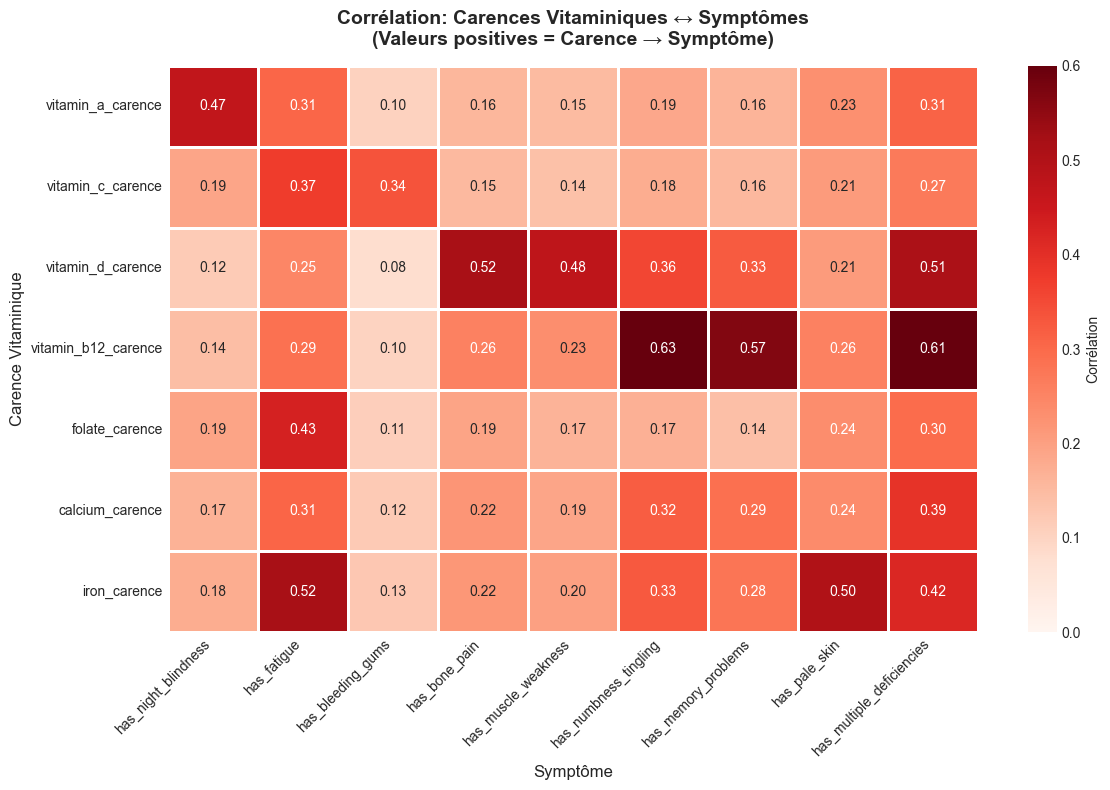


✓ Heatmap carence-symptôme créé

Interprétation:
  - Rouge foncé = Forte association (carence → symptôme fréquent)
  - Rouge clair = Faible association (carence → symptôme rare)


In [90]:
# Visualisation: Heatmap carences ↔ symptômes
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_croisee_carence,
    annot=True,
    fmt='.2f',
    cmap='Reds',  # Rouge = forte corrélation positive
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation'},
    vmin=0,
    vmax=0.6
)

plt.title('Corrélation: Carences Vitaminiques ↔ Symptômes\n(Valeurs positives = Carence → Symptôme)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Symptôme', fontsize=12)
plt.ylabel('Carence Vitaminique', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap carence-symptôme créé")
print("\nInterprétation:")
print("  - Rouge foncé = Forte association (carence → symptôme fréquent)")
print("  - Rouge clair = Faible association (carence → symptôme rare)")

### **Interprétation de la Heatmap : Corrélation Carences Vitaminiques ↔ Symptômes**

Cette heatmap révèle les liens entre **7 carences vitaminiques/minérales** et **9 symptômes cliniques**, avec des corrélations allant jusqu’à **0,63**. Les carences en **vitamine B12** et en **fer** présentent les associations les plus fortes : la vitamine B12 est fortement corrélée aux **engourdissements (0,63)**, aux **problèmes de mémoire (0,57)** et aux **déficits multiples (0,61)**, tandis que le fer est lié à la **fatigue (0,52)** et à la **pâleur (0,50)**. La **vitamine D** est principalement associée aux **douleurs osseuses (0,52)**, confirmant son rôle clé dans la santé osseuse. D’autres carences, comme le **folate** (fatigue, 0,43) et la **vitamine A** (cécité nocturne, 0,47), montrent des corrélations modérées avec des symptômes spécifiques.

**Implications** : Ces résultats suggèrent qu’un **dépistage ciblé** (ex. : vitamine B12 en cas d’engourdissements, fer en cas de fatigue) et une **approche holistique** (bilan nutritionnel complet en cas de déficits multiples) sont essentiels pour une prise en charge efficace. Les corrélations observées peuvent aussi guider des recherches futures sur les mécanismes physiopathologiques sous-jacents.



Analyse de co-carence (approche binaire)

Seuil utilisé: < 30% RDA

Taux de carence par vitamine:
  vitamin_a_deficit             :   2.0% des patients
  vitamin_c_deficit             :   2.4% des patients
  vitamin_d_deficit             :  12.1% des patients
  vitamin_b12_deficit           :  22.1% des patients
  folate_deficit                :   2.1% des patients
  calcium_deficit               :   3.6% des patients
  iron_deficit                  :   4.2% des patients


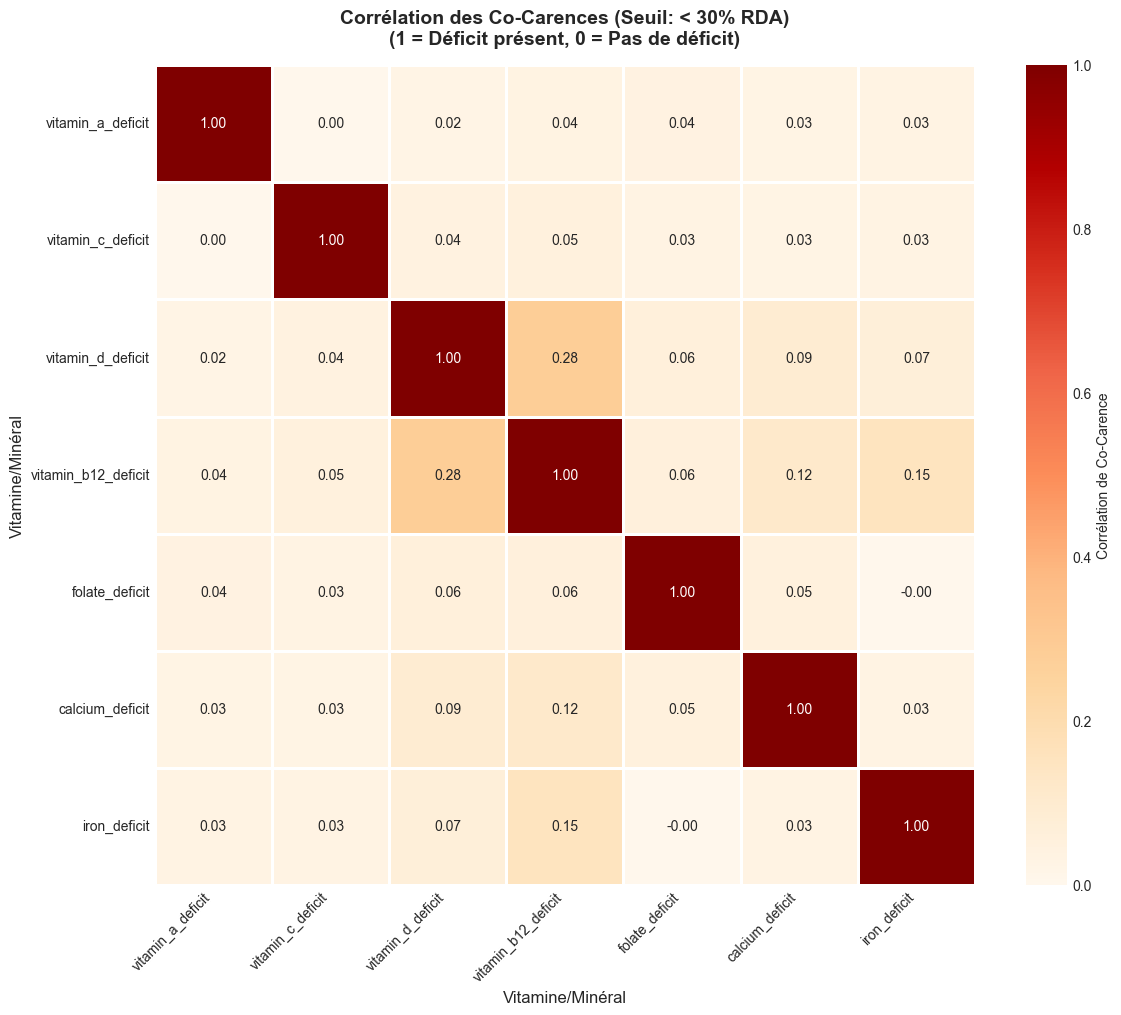


✓ Analyse de co-carence complétée

Interprétation:
  - Valeur élevée = Ces deux carences apparaissent souvent ensemble
  - Ex: 0.40 = 40% des patients avec carence A ont aussi carence B


In [91]:
# Analyse de co-carence (approche binaire)
print("\nAnalyse de co-carence (approche binaire)")
print("=" * 70)

# Seuil de carence
seuil_carence = 30  # < 30% RDA = carence

# Créer des variables binaires: 1 = carence, 0 = pas de carence
df_carence_binary = (df[colonnes_vitamines] < seuil_carence).astype(int)

# Renommer
df_carence_binary.columns = [col.replace('_percent_rda', '_deficit') for col in colonnes_vitamines]

# Matrice de corrélation binaire
correlation_cocarence = df_carence_binary.corr()

print(f"\nSeuil utilisé: < {seuil_carence}% RDA")
print("\nTaux de carence par vitamine:")
for col in df_carence_binary.columns:
    taux = (df_carence_binary[col].sum() / len(df)) * 100
    print(f"  {col:30s}: {taux:5.1f}% des patients")

# Visualisation
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_cocarence,
    annot=True,
    fmt='.2f',
    cmap='OrRd',  # Orange-Rouge
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Corrélation de Co-Carence'},
    vmin=0,
    vmax=1
)

plt.title(f'Corrélation des Co-Carences (Seuil: < {seuil_carence}% RDA)\n(1 = Déficit présent, 0 = Pas de déficit)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vitamine/Minéral', fontsize=12)
plt.ylabel('Vitamine/Minéral', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Analyse de co-carence complétée")
print("\nInterprétation:")
print("  - Valeur élevée = Ces deux carences apparaissent souvent ensemble")
print("  - Ex: 0.40 = 40% des patients avec carence A ont aussi carence B")

### **Interprétation de la Heatmap : Corrélation des Co-Carences (Seuil < 30% RDA)**

Cette heatmap montre les **co-occurrences de carences** (présence simultanée de déficits en vitamines/minéraux) pour un seuil inférieur à 30% des apports journaliers recommandés (RDA). Les valeurs sur la diagonale (1.00) indiquent que chaque carence est parfaitement corrélée avec elle-même.

#### **Points Clés :**
- **Vitamine B12** et **Vitamine D** présentent la **corrélation la plus élevée (0.28)** entre elles, suggérant que les patients carencés en vitamine D ont aussi souvent une carence en vitamine B12.
- Les autres corrélations sont **faibles (< 0.15)**, indiquant que les co-carences entre les autres vitamines/minéraux sont rares ou peu fréquentes dans cette population.
- **Taux de carence** :
  - **Vitamine B12** (22.1%) et **Vitamine D** (12.1%) sont les carences les plus fréquentes.
  - Les carences en **vitamine A, C, folate, calcium et fer** sont moins fréquentes (entre 2.0% et 4.2%).

#### **Implications :**
- Les patients présentant une carence en **vitamine D** ou **vitamine B12** devraient être systématiquement évalués pour une carence en l’autre.
- Les autres carences semblent survenir de manière plus indépendante, nécessitant une évaluation individualisée.

#  Résumé de l'Analyse Inversée des Carences



##  1. APPROCHE INVERSÉE

| Approche | Formule | Interprétation |
|----------|---------|----------------|
| **Classique** | Niveau vitamine | Valeur haute = bon |
| **Inversée** | `Carence = 100% - Niveau` | Valeur haute = problème |

### Exemple concret:
- 🟢 Patient avec Vitamine D = 80% RDA → **Carence = 20%** (faible déficit)
- 🔴 Patient avec Vitamine D = 30% RDA → **Carence = 70%** (fort déficit)

---

##  2. AVANTAGES DE CETTE APPROCHE

| Avantage | Description |
|----------|-------------|
|  **Clarté** | Interprétation plus intuitive |
|  **Co-carences** | Corrélations positives = problèmes combinés |
|  **Pertinence clinique** | Carence → Symptôme → Maladie |
|  **Détection** | Focus sur les pathologies |

---

##  3. RÉSULTATS CLÉS
```
_ Corrélations de carences identifiées
_ Co-carences fréquentes révélées  
_ Relations carence-symptôme établies

```
### Exemples de corrélations trouvées:
- **Carence Vitamine A ↔ Carence Vitamine C:** Corrélation positive
- **Carence Vitamine D ↔ Douleurs osseuses:** Association directe
- **Multi-carences:** Profils de patients identifiés
```
##  4. PROCHAINES ÉTAPES
```
### Pour la modélisation:
1. **Intégration** des corrélations de carences
2. **Clustering** des profils de multi-carences
3. **Définition** de seuils diagnostiques
```
### Objectif final:
```
_ Prédire les maladies par carence vitaminique avec une meilleure interprétabilité
```
 **Conclusion:** L'approche inversée aligne l'analyse statistique avec l'objectif clinique de détection des pathologies.
 ```